# Baseline Methods — All Three Datasets, Combined

Runs the full 10-method baseline-methods battery on all three synthetic datasets (flat, correlated modules, correlated modules + subtypes) **in one notebook**, checkpointing between datasets so results don't get lost or cross-contaminated. Unlike the data notebooks themselves (which now contain *only* data generation), all of the model code -- setup, training, and evaluation for all 10 baseline methods -- lives directly in this notebook, organized into one big section per dataset with a mini-section per method:

1. `%run` a data notebook (generates `counts_df`/`genes_df`/`patients_df`/`cells_df` and nothing else)
2. Run the Step 12 setup cell (builds the feature matrix / train-test split) and all 10 methods (L1, STG, ElasticNet, Ridge, Group Lasso, Random Forest, XGBoost, L1-SVM, RFE, mutual-information filter) directly against that data
3. Save that dataset's results to a CSV, tagged with which dataset they came from
4. `%reset -f` to fully clear the session before moving to the next dataset — this guarantees no stale variable (e.g. `module_names` left over from a module-based dataset) can silently leak into the next one
5. Repeat for the other two datasets
6. Reload all three CSVs and compile a final cross-dataset comparison

**Locally** (this file, in `sierra-gating-project/`), the three data notebooks already sit right next to this one, so the `%run` calls below use plain local filenames and just work. **In Colab**, `%run` needs an actual local file to point at — see the Colab Setup section immediately below for what to fill in before copying this notebook into your real project.

## Colab Setup (fill in before copying this notebook into your Colab project)

Locally, this section is a complete no-op (every line is commented out) — the cell below intentionally does nothing when run in `sierra-gating-project/`, since the three data notebooks are already local files here. **When you copy this notebook into your actual Colab project, uncomment and fill in the block below**, following the token setup we walked through: create a token, store it in Colab's Secrets manager (key icon 🔑 in the left sidebar) under the name `GITHUB_TOKEN`, then uncomment these lines.

After that, for **every** `%run` cell below, comment out the "LOCAL" line and uncomment the "COLAB" line right under it (each pair is clearly labeled) so `%run` points at the cloned copy instead of a same-folder local file.

In [1]:
# ==== COLAB SETUP -- uncomment and fill in when running this in Colab ====
#
# from google.colab import userdata
# token = userdata.get('GITHUB_TOKEN')
#
# import os
# if not os.path.exists("disease-heterogeneity"):
#     !git clone -b Sierra https://{token}@github.com/carmen666666999/disease-heterogeneity.git
# else:
#     !cd disease-heterogeneity && git pull
#
# ==== END COLAB SETUP ====

print("Colab setup cell is a no-op locally -- see the markdown above for what to fill in.")

Colab setup cell is a no-op locally -- see the markdown above for what to fill in.


## Dataset 1: flat (no correlated modules, no subtypes)

A survey of feature-selection baselines run on each dataset generated by its own data notebook (methodology step 3): the two "headline" methods referenced throughout the thesis (L1-penalized logistic regression, and Stochastic Gates / STG), plus 8 more spanning every major feature-selection paradigm -- embedded-linear (ElasticNet, Ridge, Group Lasso, L1-penalized linear SVM), embedded-nonlinear (Random Forest, XGBoost), wrapper (Recursive Feature Elimination), and filter (mutual-information univariate selection).

**How "recovery" is measured, uniformly across all 10 methods:** each method produces a boolean *selected* mask over all 1000 genes. Methods with genuine sparsity (L1, ElasticNet, Group Lasso, L1-SVM, STG) use their natural nonzero-coefficient / open-gate threshold. Methods with no built-in sparsity (Ridge, Random Forest, XGBoost) or that require a fixed budget upfront (RFE, mutual-information filter) instead take their top-100 genes by importance score -- 100 being the number of genes that are actually signal-carrying in this simulation, so "top-100" asks "if this method could only keep as many genes as there truly are relevant, how well would it do?"

Imported numpy, pandas, scipy.stats, matplotlib, seaborn
Random seed set to 42
Simulation parameters defined
Group 1 patients: 10
Group 2 patients: 10
Cells per patient: 50
Total genes: 1000
Signal genes: 100
Fold change: 3
mu_group1_signal = 6
mu_group2_signal = 2
mu_group1_background = 2
mu_group2_background = 2


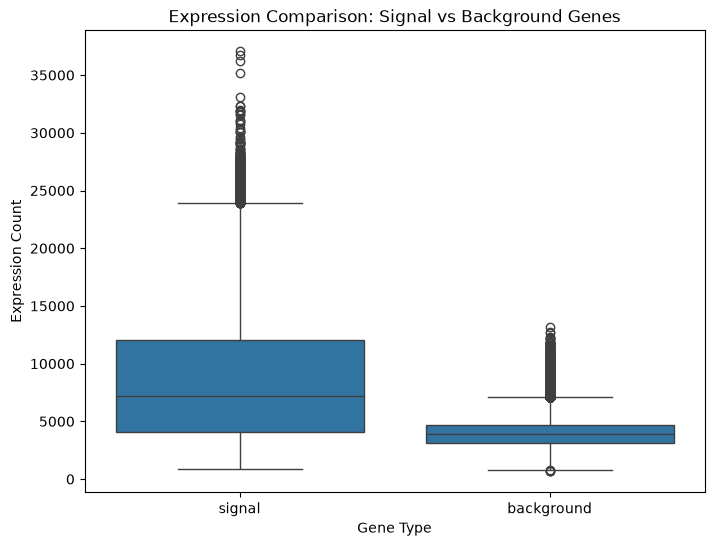

In [2]:
%run flat_syntheticdata.ipynb
# %run disease-heterogeneity/flat_syntheticdata.ipynb  # COLAB -- uncomment this line, comment out the one above

### Step 12: setup

This is where the model code actually lives now -- the data notebook above only generates `counts_df`/`genes_df`/`patients_df`/`cells_df` via `%run`. Builds the cell x gene feature matrix and the same GroupShuffleSplit-by-patient train/test split used by every method below, so all 10 methods are evaluated on identical data -- a fair, apples-to-apples comparison.

**IMPORTANT (macOS-specific, but harmless everywhere else, including Colab):** importing PyTorch (needed for STG) before XGBoost can segfault the Python process on some machines, because both libraries bundle their own OpenMP runtime and the two can conflict once both actually run in the same process. The setup cell below works around this by importing `xgboost` before `torch` and capping both libraries to 1 thread -- this must run before ANY of torch/xgboost/stg are imported.

In [3]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
os.environ["OMP_NUM_THREADS"] = "1"

import warnings
warnings.filterwarnings("ignore")

import collections
import collections.abc
for _name in ("Iterable", "Mapping", "Sequence", "Set", "MutableMapping",
              "MutableSequence", "MutableSet", "Callable", "Hashable",
              "Sized", "Container"):
    if not hasattr(collections, _name):
        setattr(collections, _name, getattr(collections.abc, _name))

from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.feature_selection import RFE, SelectKBest, mutual_info_classif
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier  # import before torch -- see note above
import torch
torch.set_num_threads(1)
from stg import STG
from group_lasso import LogisticGroupLasso

X_df = counts_df.pivot_table(
    index="cell_id", columns="gene_id", values="expression", aggfunc="sum", fill_value=0
)
cell_labels = cells_df[["cell_id", "group"]].drop_duplicates().set_index("cell_id").loc[X_df.index]
y = (cell_labels["group"] == "Group2").astype(int).values
gene_types = genes_df.set_index("gene_id").loc[X_df.columns, "gene_type"]
groups_arr = cell_labels.index.map(lambda c: c.split("_")[0]).values  # patient_id per cell

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X_df.values, y, groups=groups_arr))
X_train, X_test = X_df.values[train_idx], X_df.values[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

n_signal_total = int((gene_types == "signal").sum())
n_background_total = int((gene_types == "background").sum())
TOP_K = n_signal_total  # shared selection budget for methods with no natural sparsity

baseline_results = []  # one row per method, filled in by record_result() below
def record_result(method, train_acc, test_acc, selected_mask, extra=None):
    """selected_mask: boolean array aligned with X_df.columns (True = gene kept/selected)."""
    signal_mask = (gene_types.values == "signal")
    background_mask = (gene_types.values == "background")
    row = {
        "method": method,
        "train_acc": round(float(train_acc), 4),
        "test_acc": round(float(test_acc), 4),
        "n_selected": int(selected_mask.sum()),
        "signal_recovery_rate": round((selected_mask & signal_mask).sum() / n_signal_total, 4),
        "background_leak_rate": round((selected_mask & background_mask).sum() / n_background_total, 4),
    }
    if extra:
        row.update(extra)
    baseline_results.append(row)
    return row

print("Baseline setup complete:", X_train_scaled.shape[0], "train cells,", X_test_scaled.shape[0], "test cells,",
      X_train_scaled.shape[1], "genes")

Baseline setup complete: 800 train cells, 200 test cells, 1000 genes


### Method 1: L1-penalized logistic regression (LASSO)

The headline baseline referenced throughout the thesis. `C=0.01` was tuned so test accuracy lands in a useful, non-trivial difficulty zone (see the data-generation notebook's own parameter-tuning notes) -- retune if that notebook's Step 2 simulation parameters change.

In [4]:
model_l1 = LogisticRegression(penalty="l1", solver="saga", C=0.01, max_iter=5000, random_state=42)
model_l1.fit(X_train_scaled, y_train)
record_result("L1", model_l1.score(X_train_scaled, y_train), model_l1.score(X_test_scaled, y_test), model_l1.coef_[0] != 0)
print(baseline_results[-1])

{'method': 'L1', 'train_acc': 0.9912, 'test_acc': 0.975, 'n_selected': 35, 'signal_recovery_rate': np.float64(0.35), 'background_leak_rate': np.float64(0.0)}


### Method 2: STG (Stochastic Gates)

Yamada, Lindenbaum, Negahban & Kluger, *"Feature Selection using Stochastic Gates"* (ICML 2020) -- https://github.com/runopti/stg. Each gene gets a learnable stochastic gate trained jointly with an MLP classifier. `lam` (`=0.5`) is STG's sparsity knob; a gate is "open" (selected) if its probability exceeds 0.5. Unlike L1's convex penalty, STG's continuous/soft gating tends to keep accuracy near-ceiling across a wide `lam` range rather than smoothly trading accuracy for sparsity -- `lam` here is chosen for an illustrative gate pattern, not to match L1's accuracy.

`STG`'s `random_state` constructor argument is accepted but never actually used internally (checked the installed package source) -- `torch.manual_seed`/`np.random.seed` are set explicitly right before training instead.

In [5]:
torch.manual_seed(42)
import numpy as np
np.random.seed(42)

stg_model = STG(
    task_type="classification", input_dim=X_train_scaled.shape[1], output_dim=2,
    hidden_dims=[128, 32], activation="tanh", optimizer="Adam", learning_rate=0.01,
    batch_size=X_train_scaled.shape[0], feature_selection=True, sigma=0.5, lam=0.5,
    random_state=42, device="cpu",
)
stg_model.fit(X_train_scaled, y_train.astype(float), nr_epochs=200,
              valid_X=X_test_scaled, valid_y=y_test.astype(float), print_interval=50)

stg_gate_probs = stg_model.get_gates(mode="prob")
stg_train_acc = (stg_model.predict(X_train_scaled) == y_train).mean()
stg_test_acc = (stg_model.predict(X_test_scaled) == y_test).mean()
record_result("STG", stg_train_acc, stg_test_acc, stg_gate_probs > 0.5)
print(baseline_results[-1])

Epoch: 50: loss=0.356569 valid_loss=0.000197
Epoch: 100: loss=0.313646 valid_loss=0.000485


Epoch: 150: loss=0.302901 valid_loss=0.000958
Epoch: 200: loss=0.290091 valid_loss=0.000909


{'method': 'STG', 'train_acc': 0.9988, 'test_acc': 1.0, 'n_selected': 16, 'signal_recovery_rate': np.float64(0.16), 'background_leak_rate': np.float64(0.0)}


### Method 3: ElasticNet

Logistic regression with a 50/50 mix of L1 and L2 penalties (`l1_ratio=0.5`). Expected to be noticeably less sparse than pure L1 -- the L2 component tends to keep correlated/redundant predictors together instead of arbitrarily zeroing most of them out, so a higher recovery rate here than L1's is expected behavior, not a bug.

In [6]:
model_en = LogisticRegression(penalty="elasticnet", solver="saga", l1_ratio=0.5, C=0.01, max_iter=5000, random_state=42)
model_en.fit(X_train_scaled, y_train)
record_result("ElasticNet", model_en.score(X_train_scaled, y_train), model_en.score(X_test_scaled, y_test), model_en.coef_[0] != 0)
print(baseline_results[-1])

{'method': 'ElasticNet', 'train_acc': 0.9975, 'test_acc': 0.995, 'n_selected': 83, 'signal_recovery_rate': np.float64(0.83), 'background_leak_rate': np.float64(0.0)}


### Method 4: Ridge (L2-only)

Pure L2 penalty -- **never produces an exactly-zero coefficient**, so "nonzero count" isn't a meaningful sparsity metric here. Instead, "selected" = the top-`TOP_K` genes by `|coefficient|`, i.e. "if forced to pick only as many genes as are truly relevant, which ones would Ridge's coefficient ranking pick?"

In [7]:
model_ridge = LogisticRegression(penalty="l2", C=1.0, max_iter=5000, random_state=42)
model_ridge.fit(X_train_scaled, y_train)
ridge_selected = np.zeros(X_train_scaled.shape[1], dtype=bool)
ridge_selected[np.argsort(-np.abs(model_ridge.coef_[0]))[:TOP_K]] = True
record_result("Ridge (top-K)", model_ridge.score(X_train_scaled, y_train), model_ridge.score(X_test_scaled, y_test), ridge_selected)
print(baseline_results[-1])

{'method': 'Ridge (top-K)', 'train_acc': 1.0, 'test_acc': 1.0, 'n_selected': 100, 'signal_recovery_rate': np.float64(1.0), 'background_leak_rate': np.float64(0.0)}


### Method 5: Group Lasso

Group Lasso (Yuan & Lin 2006) shrinks whole predefined groups of features toward zero together -- an existing, simple version of "group-aware" sparsity. **This flat dataset has no real gene groups** (that's the whole point of this dataset), so every gene gets its own singleton group, which makes Group Lasso behave like an ungrouped lasso here. Included anyway for consistency across all three datasets -- the *interesting* comparison is this same method on the correlated datasets below, where real groups exist.

In [8]:
gl_groups = np.arange(X_train_scaled.shape[1])  # no real groups in this flat design -- singleton per gene

model_gl = LogisticGroupLasso(groups=gl_groups, group_reg=0.05, l1_reg=0.0, n_iter=100, random_state=42, supress_warning=True)
model_gl.fit(X_train_scaled, y_train)
gl_train_acc = (model_gl.predict(X_train_scaled) == y_train).mean()
gl_test_acc = (model_gl.predict(X_test_scaled) == y_test).mean()
record_result("GroupLasso", gl_train_acc, gl_test_acc, model_gl.sparsity_mask_)
print(baseline_results[-1])

{'method': 'GroupLasso', 'train_acc': 0.9975, 'test_acc': 0.99, 'n_selected': 56, 'signal_recovery_rate': np.float64(0.56), 'background_leak_rate': np.float64(0.0)}


### Method 6: Random Forest

An embedded-nonlinear baseline: feature importance from Gini impurity decrease. Like Ridge, has no natural zero-coefficient sparsity, so "selected" = top-`TOP_K` genes by `feature_importances_`.

In [9]:
model_rf = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=1)
model_rf.fit(X_train_scaled, y_train)
rf_selected = np.zeros(X_train_scaled.shape[1], dtype=bool)
rf_selected[np.argsort(-model_rf.feature_importances_)[:TOP_K]] = True
record_result("RandomForest (top-K)", model_rf.score(X_train_scaled, y_train), model_rf.score(X_test_scaled, y_test), rf_selected)
print(baseline_results[-1])

{'method': 'RandomForest (top-K)', 'train_acc': 1.0, 'test_acc': 1.0, 'n_selected': 100, 'signal_recovery_rate': np.float64(0.99), 'background_leak_rate': np.float64(0.0011)}


### Method 7: XGBoost

A gradient-boosted-tree baseline, extremely common in genomics feature-selection pipelines. `n_jobs=1` here matches the OpenMP thread-safety note in the setup cell above. Top-`TOP_K` genes by `feature_importances_` (gain-based).

In [10]:
model_xgb = XGBClassifier(n_estimators=300, max_depth=3, random_state=42, eval_metric="logloss", n_jobs=1)
model_xgb.fit(X_train_scaled, y_train)
xgb_selected = np.zeros(X_train_scaled.shape[1], dtype=bool)
xgb_selected[np.argsort(-model_xgb.feature_importances_)[:TOP_K]] = True
xgb_train_acc = (model_xgb.predict(X_train_scaled) == y_train).mean()
xgb_test_acc = (model_xgb.predict(X_test_scaled) == y_test).mean()
record_result("XGBoost (top-K)", xgb_train_acc, xgb_test_acc, xgb_selected)
print(baseline_results[-1])

{'method': 'XGBoost (top-K)', 'train_acc': 1.0, 'test_acc': 0.995, 'n_selected': 100, 'signal_recovery_rate': np.float64(0.38), 'background_leak_rate': np.float64(0.0689)}


### Method 8: L1-penalized linear SVM

A margin-based (rather than likelihood-based) embedded-linear baseline -- same sparsity mechanism as L1 logistic regression (exact zeros), different loss function underneath. Reuses L1's tuned `C=0.01` rather than being independently tuned.

In [11]:
model_svm = LinearSVC(penalty="l1", dual=False, C=0.01, max_iter=5000, random_state=42)
model_svm.fit(X_train_scaled, y_train)
record_result("LinearSVM-L1", model_svm.score(X_train_scaled, y_train), model_svm.score(X_test_scaled, y_test), model_svm.coef_[0] != 0)
print(baseline_results[-1])

{'method': 'LinearSVM-L1', 'train_acc': 0.9975, 'test_acc': 0.995, 'n_selected': 44, 'signal_recovery_rate': np.float64(0.37), 'background_leak_rate': np.float64(0.0078)}


### Method 9: Recursive Feature Elimination (RFE)

A wrapper method: repeatedly fits a base estimator (logistic regression here), drops the weakest-ranked features, and refits, until `TOP_K` genes remain. `step=50` (drop 50 genes per iteration, not 1) keeps runtime reasonable on 1000 features.

In [12]:
base_estimator = LogisticRegression(max_iter=1000, random_state=42)
model_rfe = RFE(estimator=base_estimator, n_features_to_select=TOP_K, step=50)
model_rfe.fit(X_train_scaled, y_train)
record_result("RFE (top-K)", model_rfe.score(X_train_scaled, y_train), model_rfe.score(X_test_scaled, y_test), model_rfe.support_)
print(baseline_results[-1])

{'method': 'RFE (top-K)', 'train_acc': 1.0, 'test_acc': 1.0, 'n_selected': 100, 'signal_recovery_rate': np.float64(0.89), 'background_leak_rate': np.float64(0.0122)}


### Method 10: Mutual-information filter (SelectKBest)

A filter method: scores every gene independently by mutual information with the group label, no classifier involved in the ranking itself. Top-`TOP_K` genes are then handed to a plain logistic regression just to report an accuracy number -- the selection itself doesn't depend on that classifier.

In [13]:
selector_mi = SelectKBest(mutual_info_classif, k=TOP_K)
selector_mi.fit(X_train_scaled, y_train)
mi_selected = selector_mi.get_support()

model_on_mi = LogisticRegression(max_iter=2000, random_state=42)
model_on_mi.fit(X_train_scaled[:, mi_selected], y_train)
mi_train_acc = model_on_mi.score(X_train_scaled[:, mi_selected], y_train)
mi_test_acc = model_on_mi.score(X_test_scaled[:, mi_selected], y_test)
record_result("SelectKBest-MI (top-K)", mi_train_acc, mi_test_acc, mi_selected)
print(baseline_results[-1])

{'method': 'SelectKBest-MI (top-K)', 'train_acc': 0.9988, 'test_acc': 0.995, 'n_selected': 100, 'signal_recovery_rate': np.float64(1.0), 'background_leak_rate': np.float64(0.0)}


### Step 23: full comparison across all 10 methods

                method  train_acc  test_acc  n_selected  signal_recovery_rate  background_leak_rate
                    L1     0.9912     0.975          35                  0.35                0.0000
                   STG     0.9988     1.000          16                  0.16                0.0000
            ElasticNet     0.9975     0.995          83                  0.83                0.0000
         Ridge (top-K)     1.0000     1.000         100                  1.00                0.0000
            GroupLasso     0.9975     0.990          56                  0.56                0.0000
  RandomForest (top-K)     1.0000     1.000         100                  0.99                0.0011
       XGBoost (top-K)     1.0000     0.995         100                  0.38                0.0689
          LinearSVM-L1     0.9975     0.995          44                  0.37                0.0078
           RFE (top-K)     1.0000     1.000         100                  0.89                0.0122


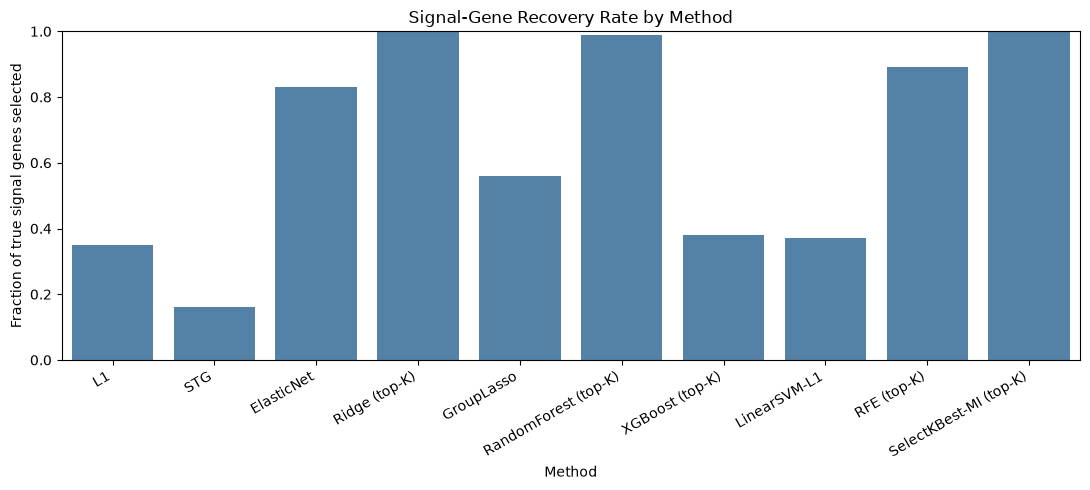

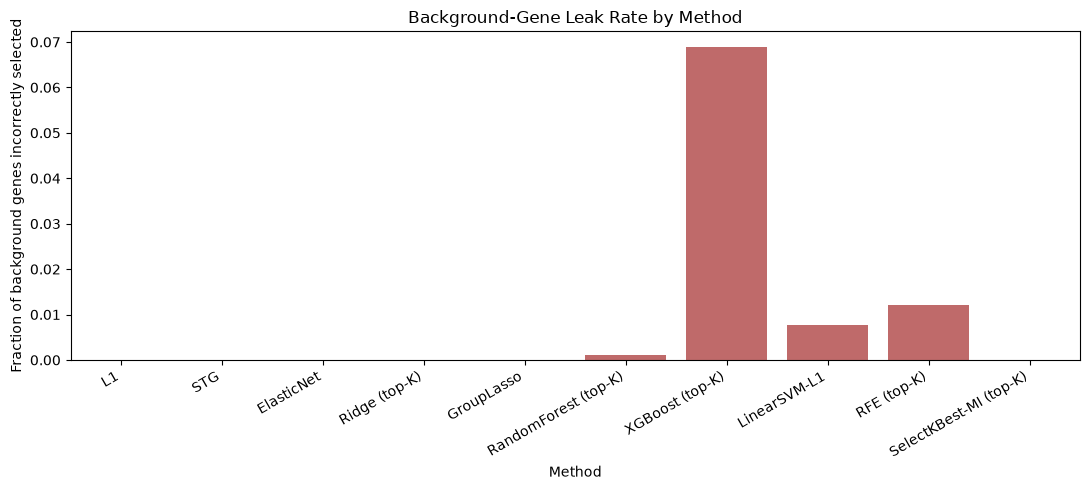

In [14]:
baseline_df = pd.DataFrame(baseline_results)
print(baseline_df.to_string(index=False))

plt.figure(figsize=(11, 5))
sns.barplot(data=baseline_df, x="method", y="signal_recovery_rate", color="steelblue")
plt.title("Signal-Gene Recovery Rate by Method")
plt.xlabel("Method")
plt.ylabel("Fraction of true signal genes selected")
plt.xticks(rotation=30, ha="right")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

plt.figure(figsize=(11, 5))
sns.barplot(data=baseline_df, x="method", y="background_leak_rate", color="indianred")
plt.title("Background-Gene Leak Rate by Method")
plt.xlabel("Method")
plt.ylabel("Fraction of background genes incorrectly selected")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

In [15]:
flat_baseline_results = baseline_df.copy()
flat_baseline_results["dataset"] = "flat"
flat_baseline_results.to_csv("flat_baseline_results.csv", index=False)
print("Saved flat_baseline_results.csv:", flat_baseline_results.shape)

Saved flat_baseline_results.csv: (10, 7)


In [16]:
%reset -f

## Dataset 2: correlated (4 gene modules, no subtypes)

A survey of feature-selection baselines run on each dataset generated by its own data notebook (methodology step 3): the two "headline" methods referenced throughout the thesis (L1-penalized logistic regression, and Stochastic Gates / STG), plus 8 more spanning every major feature-selection paradigm -- embedded-linear (ElasticNet, Ridge, Group Lasso, L1-penalized linear SVM), embedded-nonlinear (Random Forest, XGBoost), wrapper (Recursive Feature Elimination), and filter (mutual-information univariate selection).

**How "recovery" is measured, uniformly across all 10 methods:** each method produces a boolean *selected* mask over all 1000 genes. Methods with genuine sparsity (L1, ElasticNet, Group Lasso, L1-SVM, STG) use their natural nonzero-coefficient / open-gate threshold. Methods with no built-in sparsity (Ridge, Random Forest, XGBoost) or that require a fixed budget upfront (RFE, mutual-information filter) instead take their top-100 genes by importance score -- 100 being the number of genes that are actually signal-carrying in this simulation, so "top-100" asks "if this method could only keep as many genes as there truly are relevant, how well would it do?"

Imported numpy, pandas, scipy.stats, matplotlib, seaborn
Random seed set to 42
Simulation parameters defined
Group 1 patients: 10
Group 2 patients: 10
Cells per patient: 50
Total genes: 1000
Signal genes: 100
Fold change: 3
Modules: 4 x 25 genes ( 1 distractor )
Within-module target correlation: 0.6
Correlation noise: 0.0
Disease modules (mean differs by group): ['M1', 'M2', 'M3']
Distractor modules (correlated, but NOT group-differential): ['M4']
mu_group1_signal (disease modules, Group1) = 6
mu_group2_signal (disease modules, Group2) = 2
mu_group1_background (distractor module + background, Group1) = 2
mu_group2_background (distractor module + background, Group2) = 2


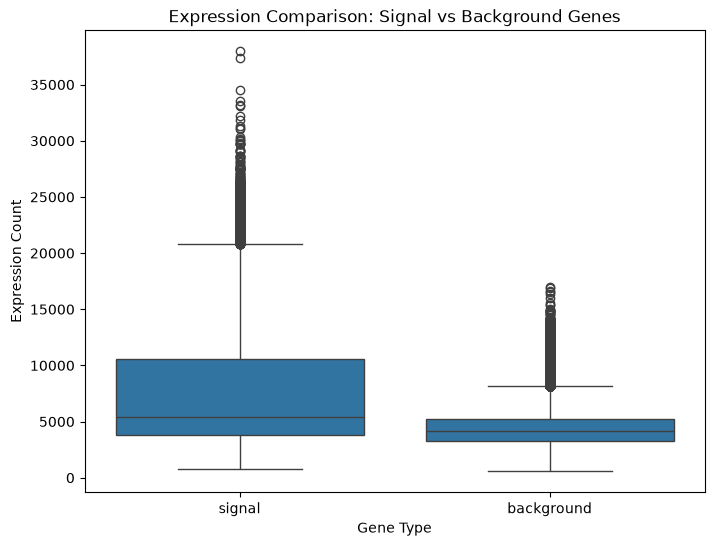

Avg pairwise correlation (normalized expression, Group1 cells only)
-----------------------------------------------------------------
M1 (disease   ): 0.594
M2 (disease   ): 0.620
M3 (disease   ): 0.586
M4 (distractor): 0.629
background   : 0.203  <- shared patient-effect floor, not leakage (see note above)


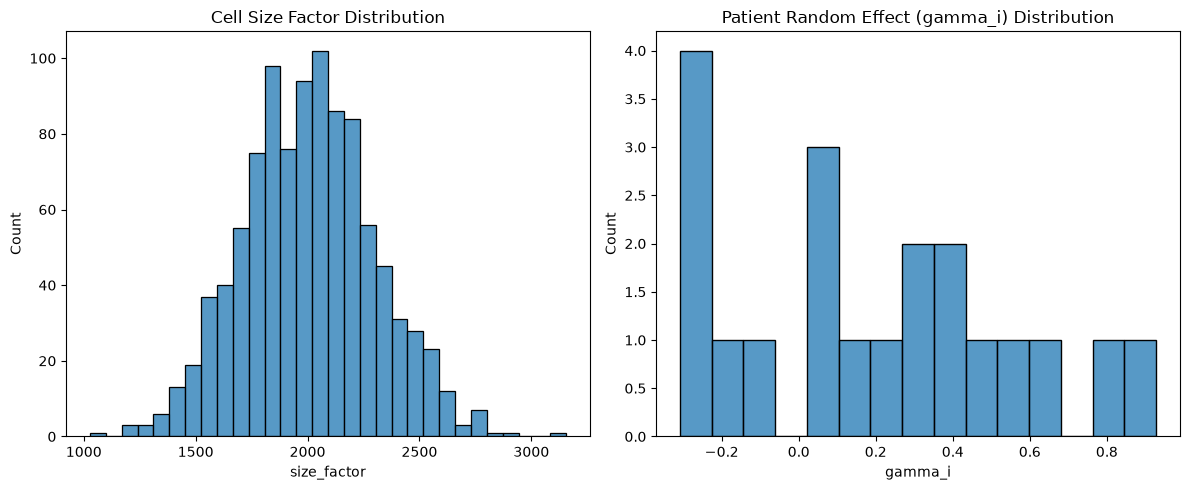

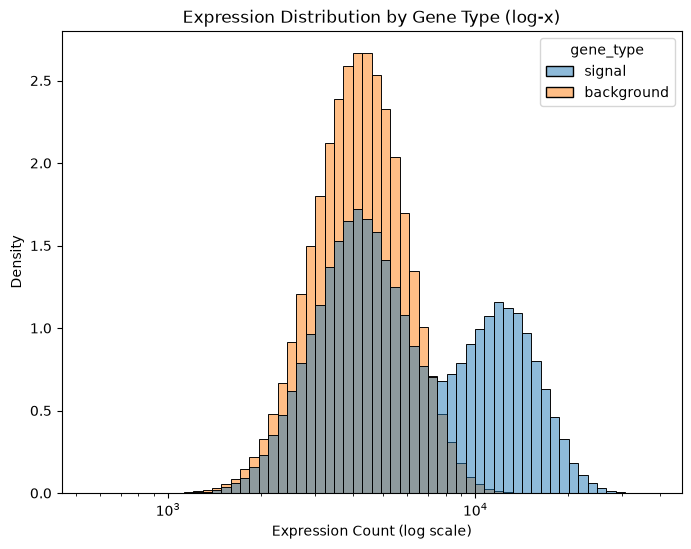

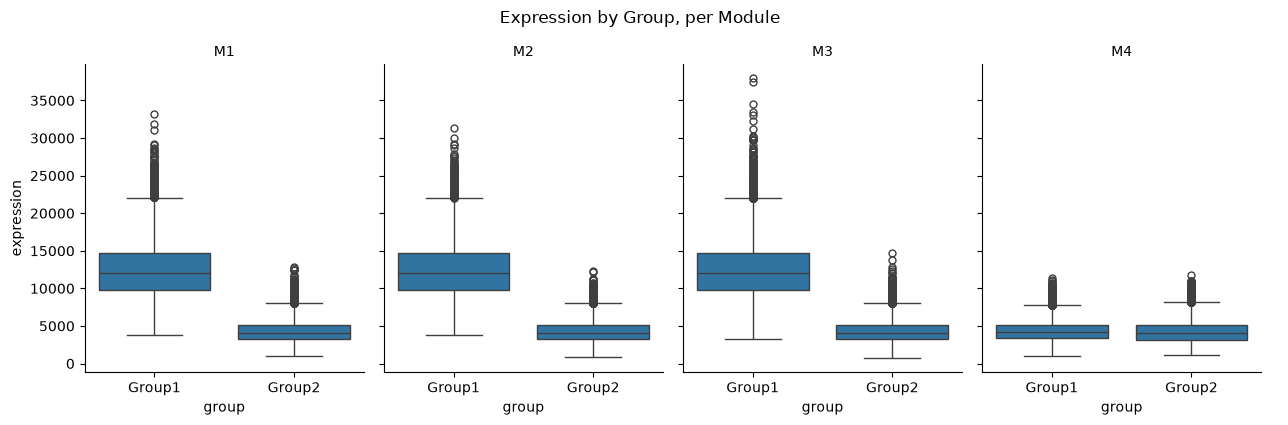

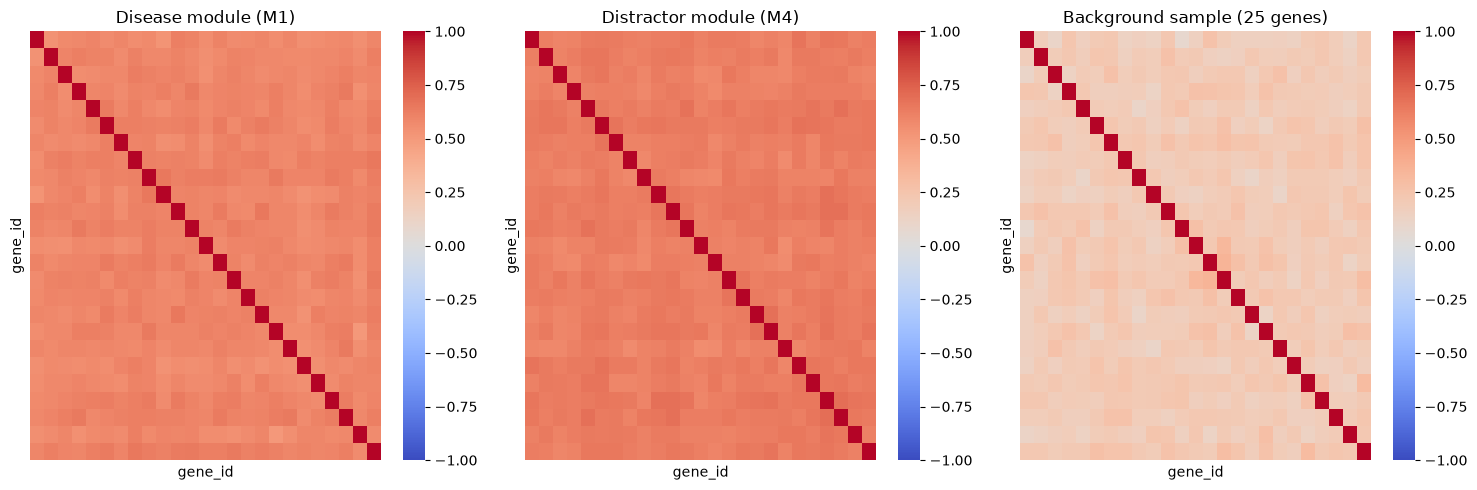

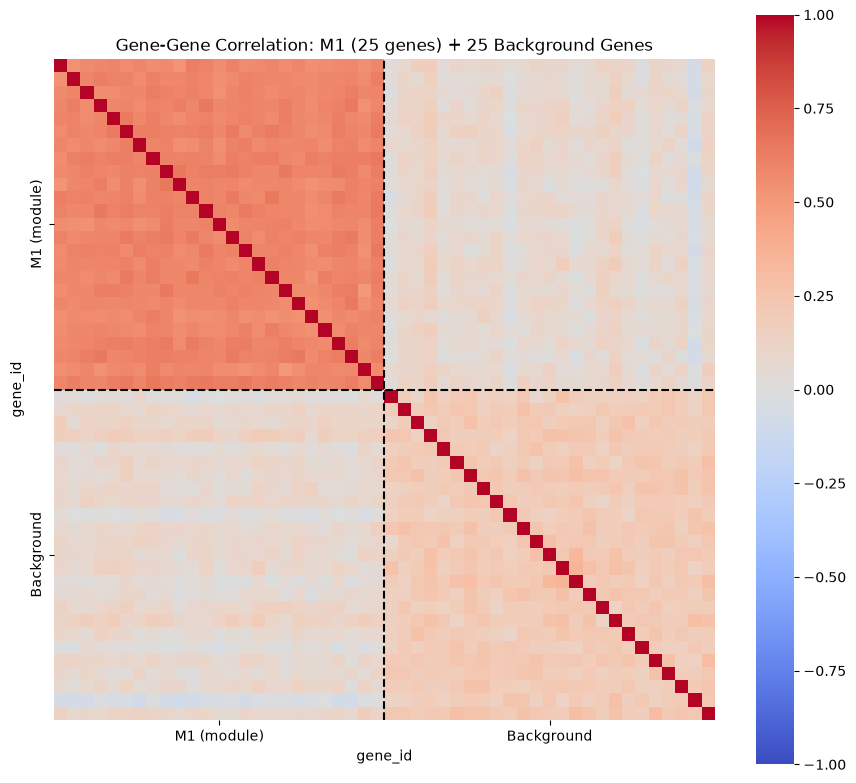

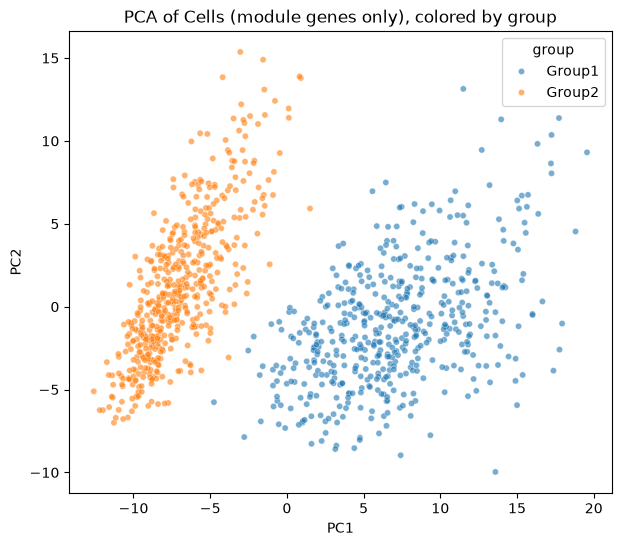

In [17]:
%run correlated_syntheticData.ipynb
# %run disease-heterogeneity/correlated_syntheticData.ipynb  # COLAB -- uncomment this line, comment out the one above

### Step 12: setup

This is where the model code actually lives now -- the data notebook above only generates `counts_df`/`genes_df`/`patients_df`/`cells_df` via `%run`. Builds the cell x gene feature matrix and the same GroupShuffleSplit-by-patient train/test split used by every method below, so all 10 methods are evaluated on identical data -- a fair, apples-to-apples comparison.

**IMPORTANT (macOS-specific, but harmless everywhere else, including Colab):** importing PyTorch (needed for STG) before XGBoost can segfault the Python process on some machines, because both libraries bundle their own OpenMP runtime and the two can conflict once both actually run in the same process. The setup cell below works around this by importing `xgboost` before `torch` and capping both libraries to 1 thread -- this must run before ANY of torch/xgboost/stg are imported.

In [18]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
os.environ["OMP_NUM_THREADS"] = "1"

import warnings
warnings.filterwarnings("ignore")

import collections
import collections.abc
for _name in ("Iterable", "Mapping", "Sequence", "Set", "MutableMapping",
              "MutableSequence", "MutableSet", "Callable", "Hashable",
              "Sized", "Container"):
    if not hasattr(collections, _name):
        setattr(collections, _name, getattr(collections.abc, _name))

from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.feature_selection import RFE, SelectKBest, mutual_info_classif
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier  # import before torch -- see note above
import torch
torch.set_num_threads(1)
from stg import STG
from group_lasso import LogisticGroupLasso

X_df = counts_df.pivot_table(
    index="cell_id", columns="gene_id", values="expression", aggfunc="sum", fill_value=0
)
cell_labels = cells_df[["cell_id", "group"]].drop_duplicates().set_index("cell_id").loc[X_df.index]
y = (cell_labels["group"] == "Group2").astype(int).values
gene_types = genes_df.set_index("gene_id").loc[X_df.columns, "gene_type"]
groups_arr = cell_labels.index.map(lambda c: c.split("_")[0]).values  # patient_id per cell

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X_df.values, y, groups=groups_arr))
X_train, X_test = X_df.values[train_idx], X_df.values[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

n_signal_total = int((gene_types == "signal").sum())
n_background_total = int((gene_types == "background").sum())
TOP_K = n_signal_total  # shared selection budget for methods with no natural sparsity

baseline_results = []  # one row per method, filled in by record_result() below
module_recovery_results = []  # one row per (method, module), filled in by record_module_recovery()

def record_module_recovery(method, selected_mask):
    for module in module_names:
        module_mask = (genes_df.set_index("gene_id").loc[X_df.columns, "module_id"] == module).values
        n_in_module = int(module_mask.sum())
        n_recovered = int((selected_mask & module_mask).sum())
        module_recovery_results.append({
            "method": method, "module_id": module,
            "kind": "disease" if module in disease_modules else "distractor",
            "genes_in_module": n_in_module, "genes_recovered": n_recovered,
            "recovery_rate": round(n_recovered / n_in_module, 4)
        })

def record_result(method, train_acc, test_acc, selected_mask, extra=None):
    """selected_mask: boolean array aligned with X_df.columns (True = gene kept/selected)."""
    signal_mask = (gene_types.values == "signal")
    background_mask = (gene_types.values == "background")
    row = {
        "method": method,
        "train_acc": round(float(train_acc), 4),
        "test_acc": round(float(test_acc), 4),
        "n_selected": int(selected_mask.sum()),
        "signal_recovery_rate": round((selected_mask & signal_mask).sum() / n_signal_total, 4),
        "background_leak_rate": round((selected_mask & background_mask).sum() / n_background_total, 4),
    }
    if extra:
        row.update(extra)
    baseline_results.append(row)
    record_module_recovery(method, selected_mask)
    return row

print("Baseline setup complete:", X_train_scaled.shape[0], "train cells,", X_test_scaled.shape[0], "test cells,",
      X_train_scaled.shape[1], "genes")

Baseline setup complete: 800 train cells, 200 test cells, 1000 genes


### Method 1: L1-penalized logistic regression (LASSO)

The headline baseline referenced throughout the thesis. `C=0.0054` was tuned so test accuracy lands in a useful, non-trivial difficulty zone (see the data-generation notebook's own parameter-tuning notes) -- retune if that notebook's Step 2 simulation parameters change.

In [19]:
model_l1 = LogisticRegression(penalty="l1", solver="saga", C=0.0054, max_iter=5000, random_state=42)
model_l1.fit(X_train_scaled, y_train)
record_result("L1", model_l1.score(X_train_scaled, y_train), model_l1.score(X_test_scaled, y_test), model_l1.coef_[0] != 0)
print(baseline_results[-1])

{'method': 'L1', 'train_acc': 0.9337, 'test_acc': 0.805, 'n_selected': 14, 'signal_recovery_rate': np.float64(0.14), 'background_leak_rate': np.float64(0.0)}


### Method 2: STG (Stochastic Gates)

Yamada, Lindenbaum, Negahban & Kluger, *"Feature Selection using Stochastic Gates"* (ICML 2020) -- https://github.com/runopti/stg. Each gene gets a learnable stochastic gate trained jointly with an MLP classifier. `lam` (`=0.2`) is STG's sparsity knob; a gate is "open" (selected) if its probability exceeds 0.5. Unlike L1's convex penalty, STG's continuous/soft gating tends to keep accuracy near-ceiling across a wide `lam` range rather than smoothly trading accuracy for sparsity -- `lam` here is chosen for an illustrative gate pattern, not to match L1's accuracy.

`STG`'s `random_state` constructor argument is accepted but never actually used internally (checked the installed package source) -- `torch.manual_seed`/`np.random.seed` are set explicitly right before training instead.

In [20]:
torch.manual_seed(42)
import numpy as np
np.random.seed(42)

stg_model = STG(
    task_type="classification", input_dim=X_train_scaled.shape[1], output_dim=2,
    hidden_dims=[128, 32], activation="tanh", optimizer="Adam", learning_rate=0.01,
    batch_size=X_train_scaled.shape[0], feature_selection=True, sigma=0.5, lam=0.2,
    random_state=42, device="cpu",
)
stg_model.fit(X_train_scaled, y_train.astype(float), nr_epochs=200,
              valid_X=X_test_scaled, valid_y=y_test.astype(float), print_interval=50)

stg_gate_probs = stg_model.get_gates(mode="prob")
stg_train_acc = (stg_model.predict(X_train_scaled) == y_train).mean()
stg_test_acc = (stg_model.predict(X_test_scaled) == y_test).mean()
record_result("STG", stg_train_acc, stg_test_acc, stg_gate_probs > 0.5)
print(baseline_results[-1])

Epoch: 50: loss=0.161168 valid_loss=0.000292
Epoch: 100: loss=0.158101 valid_loss=0.000399


Epoch: 150: loss=0.157064 valid_loss=0.000726


Epoch: 200: loss=0.156545 valid_loss=0.000740
{'method': 'STG', 'train_acc': 1.0, 'test_acc': 1.0, 'n_selected': 10, 'signal_recovery_rate': np.float64(0.1), 'background_leak_rate': np.float64(0.0)}


### Method 3: ElasticNet

Logistic regression with a 50/50 mix of L1 and L2 penalties (`l1_ratio=0.5`). Expected to be noticeably less sparse than pure L1 -- the L2 component tends to keep correlated/redundant predictors together instead of arbitrarily zeroing most of them out, so a higher recovery rate here than L1's is expected behavior, not a bug.

In [21]:
model_en = LogisticRegression(penalty="elasticnet", solver="saga", l1_ratio=0.5, C=0.0054, max_iter=5000, random_state=42)
model_en.fit(X_train_scaled, y_train)
record_result("ElasticNet", model_en.score(X_train_scaled, y_train), model_en.score(X_test_scaled, y_test), model_en.coef_[0] != 0)
print(baseline_results[-1])

{'method': 'ElasticNet', 'train_acc': 0.9762, 'test_acc': 0.94, 'n_selected': 74, 'signal_recovery_rate': np.float64(0.74), 'background_leak_rate': np.float64(0.0)}


### Method 4: Ridge (L2-only)

Pure L2 penalty -- **never produces an exactly-zero coefficient**, so "nonzero count" isn't a meaningful sparsity metric here. Instead, "selected" = the top-`TOP_K` genes by `|coefficient|`, i.e. "if forced to pick only as many genes as are truly relevant, which ones would Ridge's coefficient ranking pick?"

In [22]:
model_ridge = LogisticRegression(penalty="l2", C=1.0, max_iter=5000, random_state=42)
model_ridge.fit(X_train_scaled, y_train)
ridge_selected = np.zeros(X_train_scaled.shape[1], dtype=bool)
ridge_selected[np.argsort(-np.abs(model_ridge.coef_[0]))[:TOP_K]] = True
record_result("Ridge (top-K)", model_ridge.score(X_train_scaled, y_train), model_ridge.score(X_test_scaled, y_test), ridge_selected)
print(baseline_results[-1])

{'method': 'Ridge (top-K)', 'train_acc': 1.0, 'test_acc': 1.0, 'n_selected': 100, 'signal_recovery_rate': np.float64(0.75), 'background_leak_rate': np.float64(0.0278)}


### Method 5: Group Lasso

The most directly relevant baseline for this thesis: Group Lasso (Yuan & Lin 2006) already treats predefined groups of features as a unit, shrinking whole groups toward zero together -- a simple, existing version of "group-aware" sparsity that the eventual group-aware gating framework (methodology step 4) should be compared against. Genes are grouped by their true `module_id` (background genes each get their own singleton "group", since they don't belong to a real module). Uses the `group-lasso` package's `LogisticGroupLasso`.

In [23]:
gl_groups = np.where(
    (genes_df.set_index("gene_id").loc[X_df.columns, "module_id"] == "none").values,
    np.arange(len(X_df.columns)) + 1000,  # background genes: distinct singleton groups
    genes_df.set_index("gene_id").loc[X_df.columns, "module_id"].astype("category").cat.codes.values
)

model_gl = LogisticGroupLasso(groups=gl_groups, group_reg=0.05, l1_reg=0.0, n_iter=100, random_state=42, supress_warning=True)
model_gl.fit(X_train_scaled, y_train)
gl_train_acc = (model_gl.predict(X_train_scaled) == y_train).mean()
gl_test_acc = (model_gl.predict(X_test_scaled) == y_test).mean()
record_result("GroupLasso", gl_train_acc, gl_test_acc, model_gl.sparsity_mask_)
print(baseline_results[-1])

{'method': 'GroupLasso', 'train_acc': 0.9788, 'test_acc': 0.965, 'n_selected': 64, 'signal_recovery_rate': np.float64(0.64), 'background_leak_rate': np.float64(0.0)}


### Method 6: Random Forest

An embedded-nonlinear baseline: feature importance from Gini impurity decrease. Like Ridge, has no natural zero-coefficient sparsity, so "selected" = top-`TOP_K` genes by `feature_importances_`.

In [24]:
model_rf = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=1)
model_rf.fit(X_train_scaled, y_train)
rf_selected = np.zeros(X_train_scaled.shape[1], dtype=bool)
rf_selected[np.argsort(-model_rf.feature_importances_)[:TOP_K]] = True
record_result("RandomForest (top-K)", model_rf.score(X_train_scaled, y_train), model_rf.score(X_test_scaled, y_test), rf_selected)
print(baseline_results[-1])

{'method': 'RandomForest (top-K)', 'train_acc': 1.0, 'test_acc': 1.0, 'n_selected': 100, 'signal_recovery_rate': np.float64(0.75), 'background_leak_rate': np.float64(0.0278)}


### Method 7: XGBoost

A gradient-boosted-tree baseline, extremely common in genomics feature-selection pipelines. `n_jobs=1` here matches the OpenMP thread-safety note in the setup cell above. Top-`TOP_K` genes by `feature_importances_` (gain-based).

In [25]:
model_xgb = XGBClassifier(n_estimators=300, max_depth=3, random_state=42, eval_metric="logloss", n_jobs=1)
model_xgb.fit(X_train_scaled, y_train)
xgb_selected = np.zeros(X_train_scaled.shape[1], dtype=bool)
xgb_selected[np.argsort(-model_xgb.feature_importances_)[:TOP_K]] = True
xgb_train_acc = (model_xgb.predict(X_train_scaled) == y_train).mean()
xgb_test_acc = (model_xgb.predict(X_test_scaled) == y_test).mean()
record_result("XGBoost (top-K)", xgb_train_acc, xgb_test_acc, xgb_selected)
print(baseline_results[-1])

{'method': 'XGBoost (top-K)', 'train_acc': 1.0, 'test_acc': 1.0, 'n_selected': 100, 'signal_recovery_rate': np.float64(0.39), 'background_leak_rate': np.float64(0.0678)}


### Method 8: L1-penalized linear SVM

A margin-based (rather than likelihood-based) embedded-linear baseline -- same sparsity mechanism as L1 logistic regression (exact zeros), different loss function underneath. Reuses L1's tuned `C=0.0054` rather than being independently tuned.

In [26]:
model_svm = LinearSVC(penalty="l1", dual=False, C=0.0054, max_iter=5000, random_state=42)
model_svm.fit(X_train_scaled, y_train)
record_result("LinearSVM-L1", model_svm.score(X_train_scaled, y_train), model_svm.score(X_test_scaled, y_test), model_svm.coef_[0] != 0)
print(baseline_results[-1])

{'method': 'LinearSVM-L1', 'train_acc': 0.9962, 'test_acc': 1.0, 'n_selected': 35, 'signal_recovery_rate': np.float64(0.28), 'background_leak_rate': np.float64(0.0078)}


### Method 9: Recursive Feature Elimination (RFE)

A wrapper method: repeatedly fits a base estimator (logistic regression here), drops the weakest-ranked features, and refits, until `TOP_K` genes remain. `step=50` (drop 50 genes per iteration, not 1) keeps runtime reasonable on 1000 features.

In [27]:
base_estimator = LogisticRegression(max_iter=1000, random_state=42)
model_rfe = RFE(estimator=base_estimator, n_features_to_select=TOP_K, step=50)
model_rfe.fit(X_train_scaled, y_train)
record_result("RFE (top-K)", model_rfe.score(X_train_scaled, y_train), model_rfe.score(X_test_scaled, y_test), model_rfe.support_)
print(baseline_results[-1])

{'method': 'RFE (top-K)', 'train_acc': 1.0, 'test_acc': 1.0, 'n_selected': 100, 'signal_recovery_rate': np.float64(0.75), 'background_leak_rate': np.float64(0.0278)}

### Method 10: Mutual-information filter (SelectKBest)

A filter method: scores every gene independently by mutual information with the group label, no classifier involved in the ranking itself. Top-`TOP_K` genes are then handed to a plain logistic regression just to report an accuracy number -- the selection itself doesn't depend on that classifier.

In [28]:
selector_mi = SelectKBest(mutual_info_classif, k=TOP_K)
selector_mi.fit(X_train_scaled, y_train)
mi_selected = selector_mi.get_support()

model_on_mi = LogisticRegression(max_iter=2000, random_state=42)
model_on_mi.fit(X_train_scaled[:, mi_selected], y_train)
mi_train_acc = model_on_mi.score(X_train_scaled[:, mi_selected], y_train)
mi_test_acc = model_on_mi.score(X_test_scaled[:, mi_selected], y_test)
record_result("SelectKBest-MI (top-K)", mi_train_acc, mi_test_acc, mi_selected)
print(baseline_results[-1])

{'method': 'SelectKBest-MI (top-K)', 'train_acc': 1.0, 'test_acc': 1.0, 'n_selected': 100, 'signal_recovery_rate': np.float64(0.77), 'background_leak_rate': np.float64(0.0256)}


### Step 23: full comparison across all 10 methods

                method  train_acc  test_acc  n_selected  signal_recovery_rate  background_leak_rate
                    L1     0.9337     0.805          14                  0.14                0.0000
                   STG     1.0000     1.000          10                  0.10                0.0000
            ElasticNet     0.9762     0.940          74                  0.74                0.0000
         Ridge (top-K)     1.0000     1.000         100                  0.75                0.0278
            GroupLasso     0.9788     0.965          64                  0.64                0.0000
  RandomForest (top-K)     1.0000     1.000         100                  0.75                0.0278
       XGBoost (top-K)     1.0000     1.000         100                  0.39                0.0678
          LinearSVM-L1     0.9962     1.000          35                  0.28                0.0078
           RFE (top-K)     1.0000     1.000         100                  0.75                0.0278


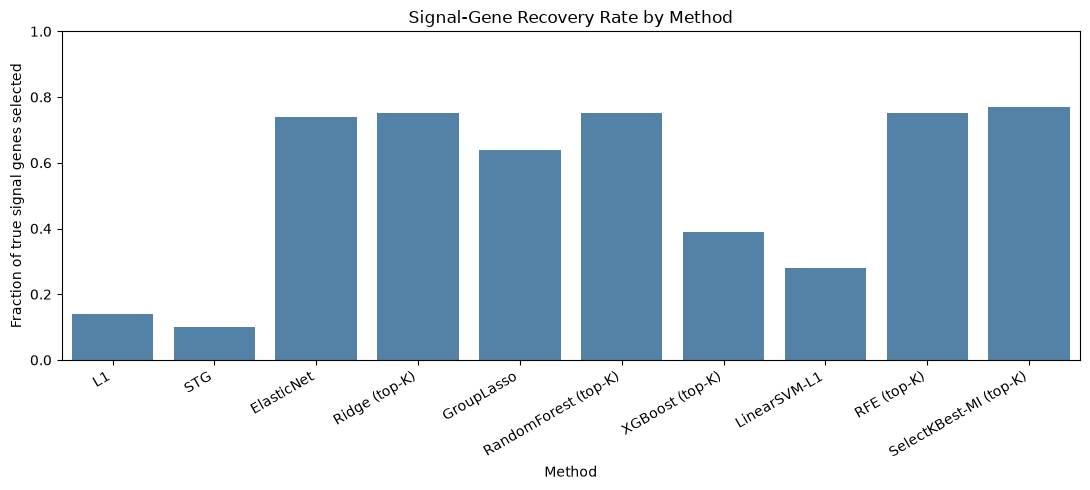

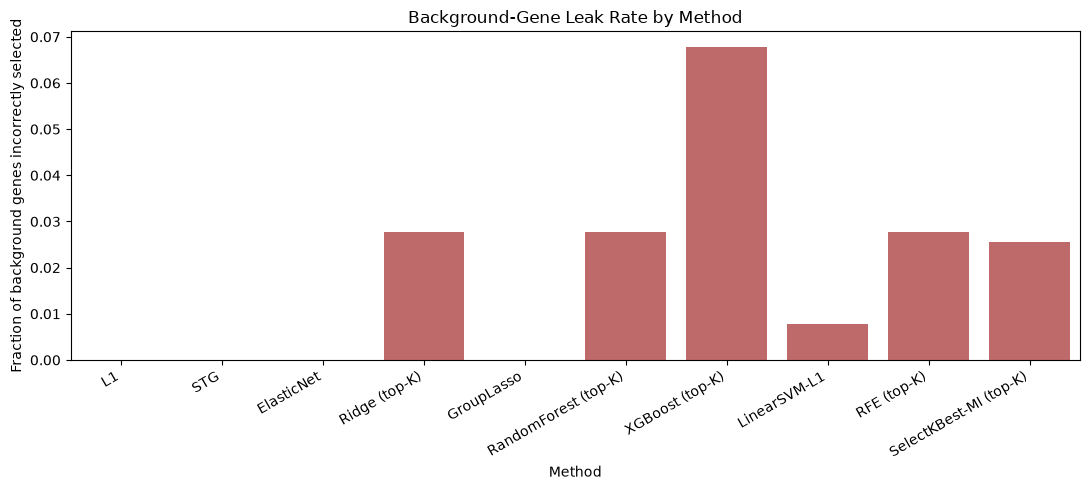


Per-module recovery rate by method:
module_id                 M1    M2    M3    M4
method                                        
ElasticNet              0.96  1.00  1.00  0.00
GroupLasso              0.88  0.88  0.80  0.00
L1                      0.24  0.12  0.20  0.00
LinearSVM-L1            0.48  0.36  0.28  0.00
RFE (top-K)             1.00  1.00  1.00  0.00
RandomForest (top-K)    1.00  1.00  1.00  0.00
Ridge (top-K)           1.00  1.00  1.00  0.00
STG                     0.16  0.08  0.16  0.00
SelectKBest-MI (top-K)  1.00  1.00  1.00  0.08
XGBoost (top-K)         0.52  0.44  0.60  0.00


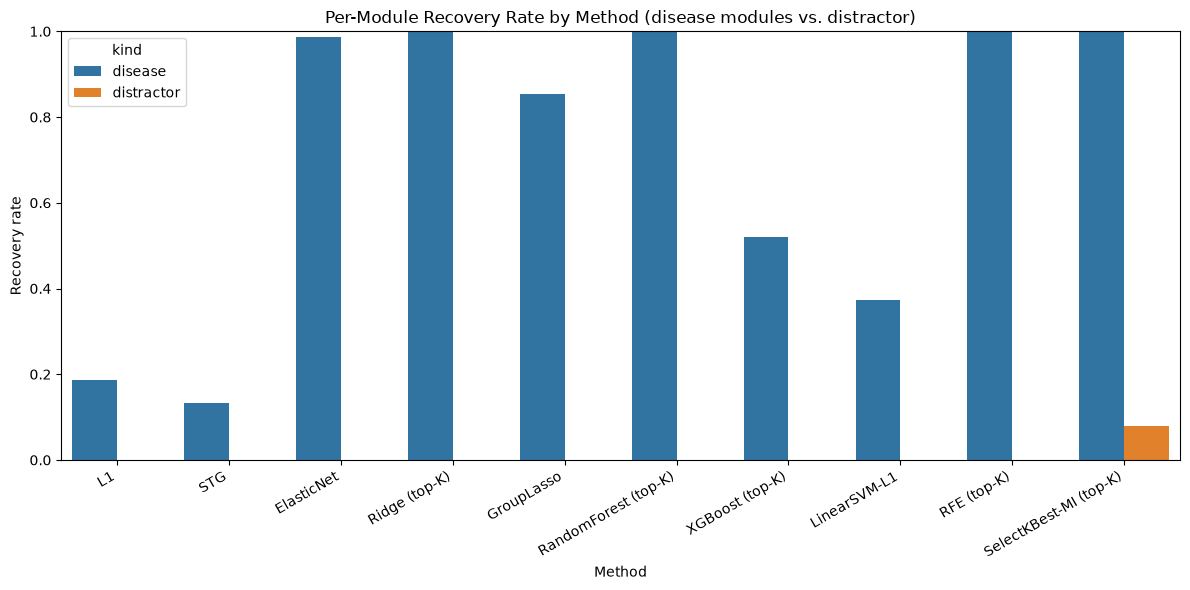

In [29]:
baseline_df = pd.DataFrame(baseline_results)
print(baseline_df.to_string(index=False))

plt.figure(figsize=(11, 5))
sns.barplot(data=baseline_df, x="method", y="signal_recovery_rate", color="steelblue")
plt.title("Signal-Gene Recovery Rate by Method")
plt.xlabel("Method")
plt.ylabel("Fraction of true signal genes selected")
plt.xticks(rotation=30, ha="right")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

plt.figure(figsize=(11, 5))
sns.barplot(data=baseline_df, x="method", y="background_leak_rate", color="indianred")
plt.title("Background-Gene Leak Rate by Method")
plt.xlabel("Method")
plt.ylabel("Fraction of background genes incorrectly selected")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

module_recovery_df = pd.DataFrame(module_recovery_results)
print("\nPer-module recovery rate by method:")
print(module_recovery_df.pivot(index="method", columns="module_id", values="recovery_rate").to_string())

plt.figure(figsize=(12, 6))
sns.barplot(data=module_recovery_df, x="method", y="recovery_rate", hue="kind", errorbar=None)
plt.title("Per-Module Recovery Rate by Method (disease modules vs. distractor)")
plt.xlabel("Method")
plt.ylabel("Recovery rate")
plt.xticks(rotation=30, ha="right")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

In [30]:
correlated_baseline_results = baseline_df.copy()
correlated_baseline_results["dataset"] = "correlated"
correlated_baseline_results.to_csv("correlated_baseline_results.csv", index=False)

correlated_module_recovery = module_recovery_df.copy()
correlated_module_recovery["dataset"] = "correlated"
correlated_module_recovery.to_csv("correlated_module_recovery.csv", index=False)

print("Saved correlated_baseline_results.csv:", correlated_baseline_results.shape)
print("Saved correlated_module_recovery.csv:", correlated_module_recovery.shape)

Saved correlated_baseline_results.csv: (10, 7)
Saved correlated_module_recovery.csv: (40, 7)


In [31]:
%reset -f

## Dataset 3: correlated + subtypes (4 gene modules, per-patient disease subtypes)

A survey of feature-selection baselines run on each dataset generated by its own data notebook (methodology step 3): the two "headline" methods referenced throughout the thesis (L1-penalized logistic regression, and Stochastic Gates / STG), plus 8 more spanning every major feature-selection paradigm -- embedded-linear (ElasticNet, Ridge, Group Lasso, L1-penalized linear SVM), embedded-nonlinear (Random Forest, XGBoost), wrapper (Recursive Feature Elimination), and filter (mutual-information univariate selection).

**How "recovery" is measured, uniformly across all 10 methods:** each method produces a boolean *selected* mask over all 1000 genes. Methods with genuine sparsity (L1, ElasticNet, Group Lasso, L1-SVM, STG) use their natural nonzero-coefficient / open-gate threshold. Methods with no built-in sparsity (Ridge, Random Forest, XGBoost) or that require a fixed budget upfront (RFE, mutual-information filter) instead take their top-100 genes by importance score -- 100 being the number of genes that are actually signal-carrying in this simulation, so "top-100" asks "if this method could only keep as many genes as there truly are relevant, how well would it do?"

Imported numpy, pandas, scipy.stats, matplotlib, seaborn
Random seed set to 42
Simulation parameters defined
Group 1 patients: 10
Group 2 patients: 10
Cells per patient: 50
Total genes: 1000
Signal genes: 100
Fold change: 3
Modules: 4 x 25 genes ( 1 distractor )
Within-module target correlation: 0.6
Correlation noise: 0.0
Subtypes: ['S1', 'S2', 'S3'] -> module indices {'S1': [0, 1], 'S2': [1, 2], 'S3': [0]}
Group1 subtype counts:
subtype
S1    4
S3    3
S2    3
Name: count, dtype: int64
Disease modules (mean differs by group): ['M1', 'M2', 'M3']
Distractor modules (correlated, but NOT group-differential): ['M4']
Subtype -> active (boosted) disease modules:
  S1: ['M1', 'M2']
  S2: ['M2', 'M3']
  S3: ['M1']
mu_group1_signal (disease modules, Group1) = 6
mu_group2_signal (disease modules, Group2) = 2
mu_group1_background (distractor module + background, Group1) = 2
mu_group2_background (distractor module + background, Group2) = 2


mu floor triggered 0 times out of 1000000 draws (0.0000%)


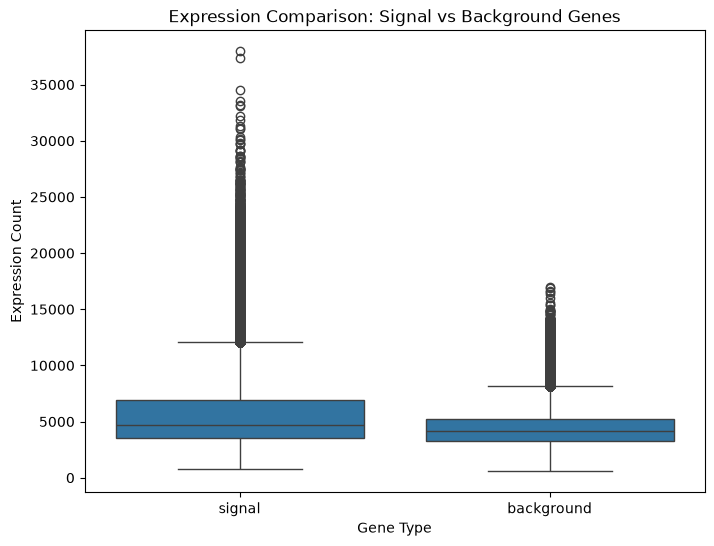

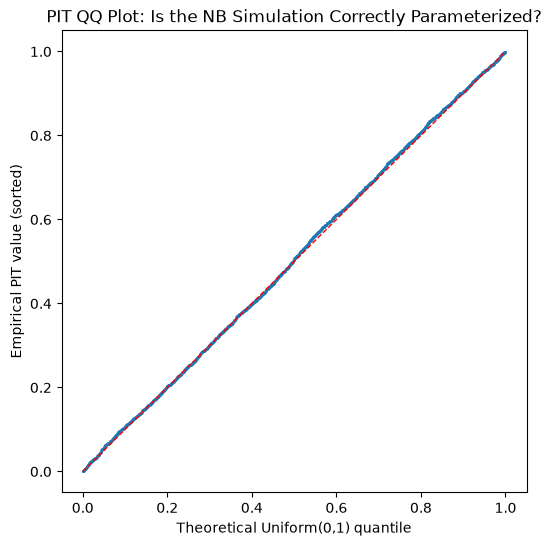

Avg pairwise correlation (normalized expression; disease modules measured
within one activating subtype's cells, distractor/background across all Group1)
------------------------------------------------------------------------------
M1 (disease   ): 0.569
M2 (disease   ): 0.628
M3 (disease   ): 0.595
M4 (distractor): 0.629
background   : 0.203  <- shared patient-effect floor, not leakage (see note above)


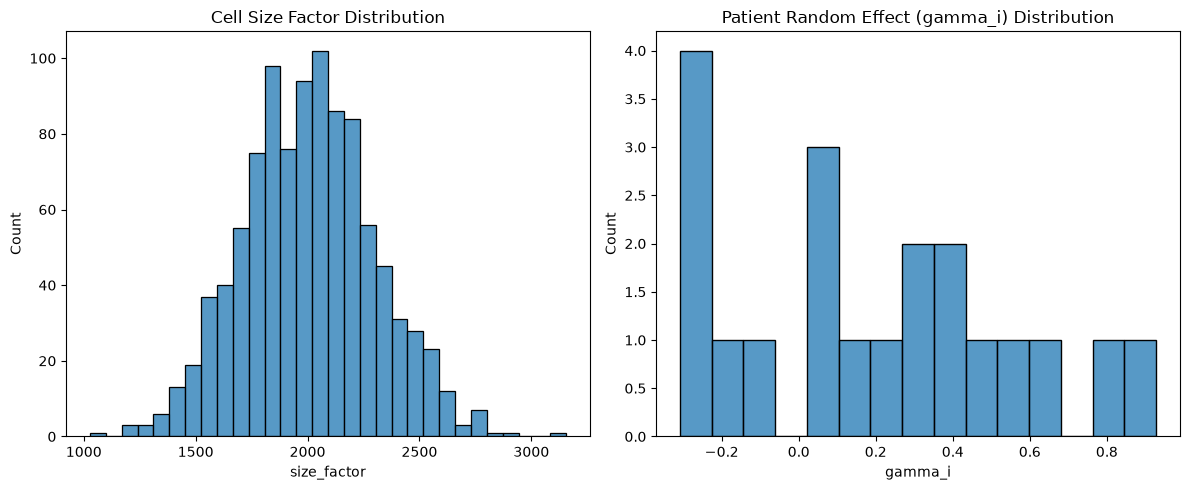

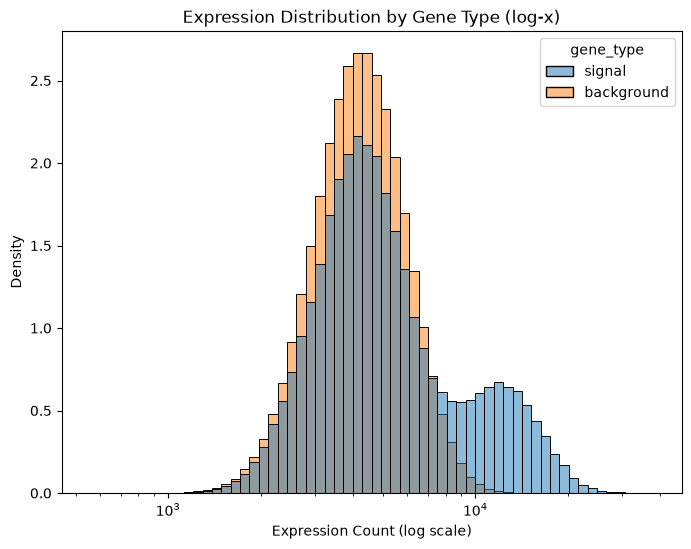

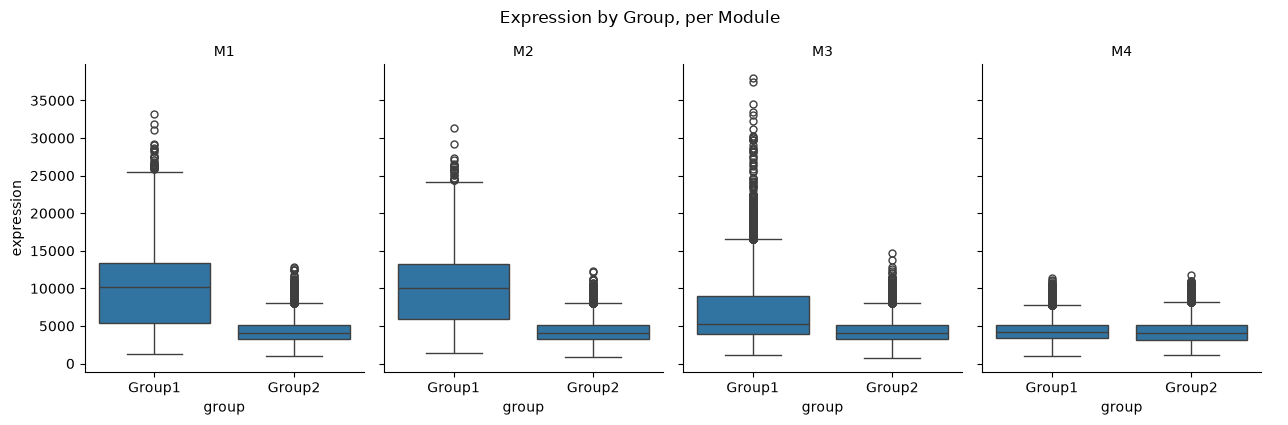

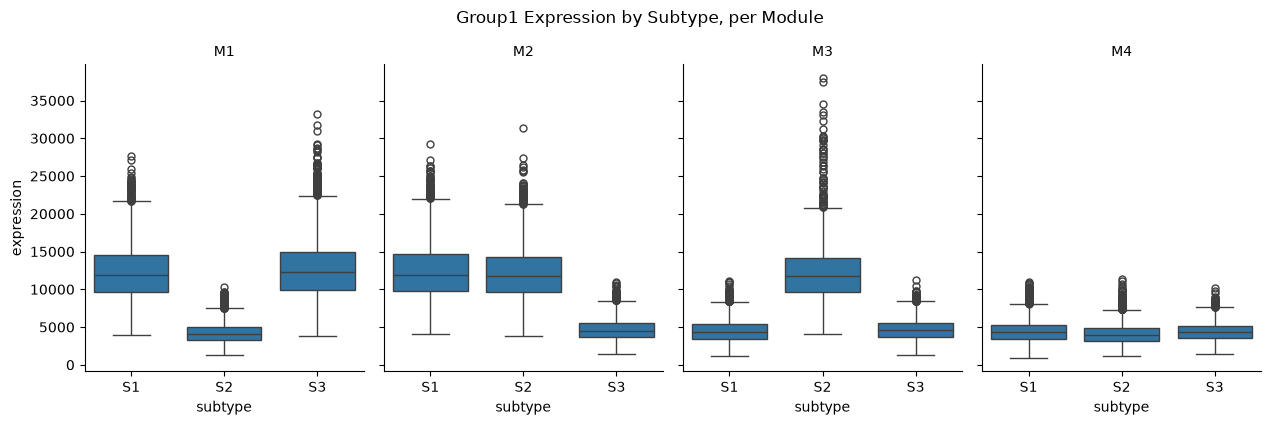

Subtype -> active (boosted) modules (should match the elevated boxes above):
  S1: ['M1', 'M2']
  S2: ['M2', 'M3']
  S3: ['M1']


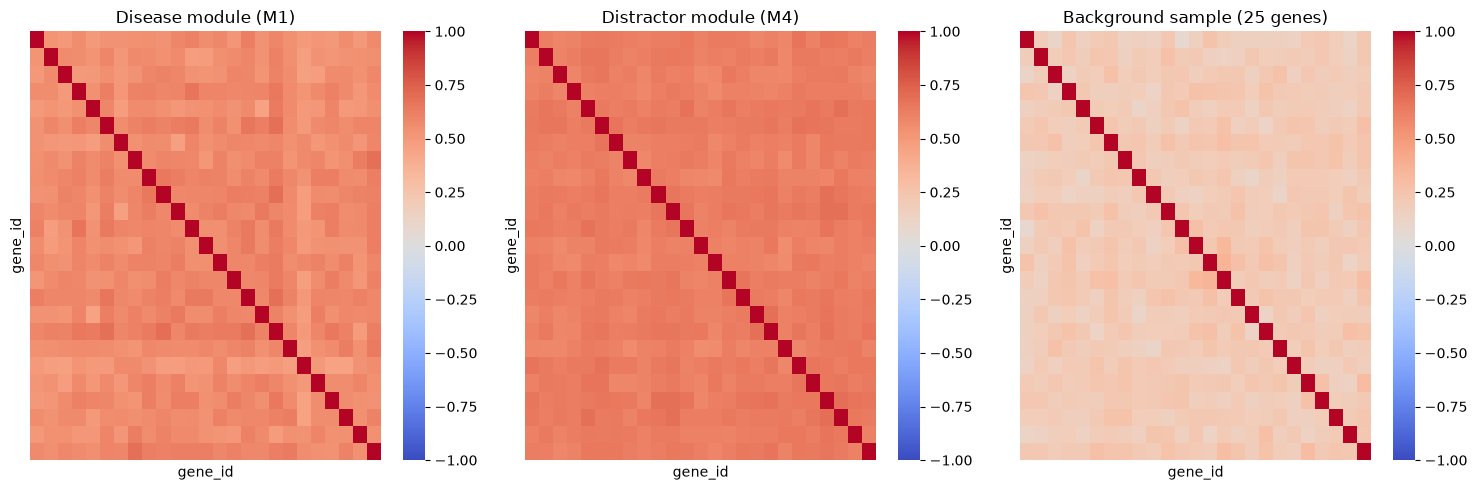

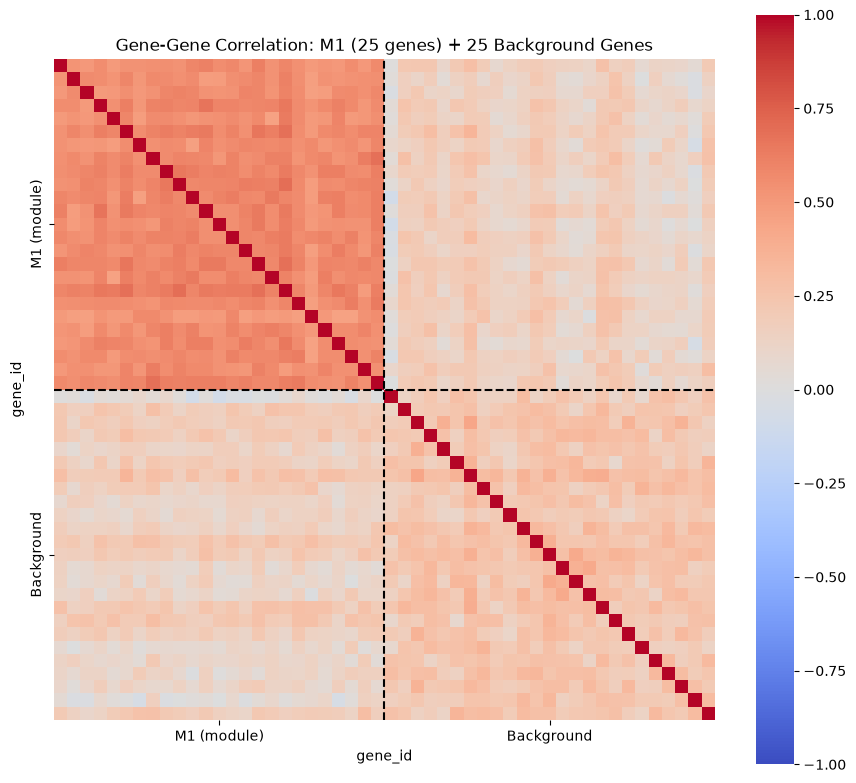

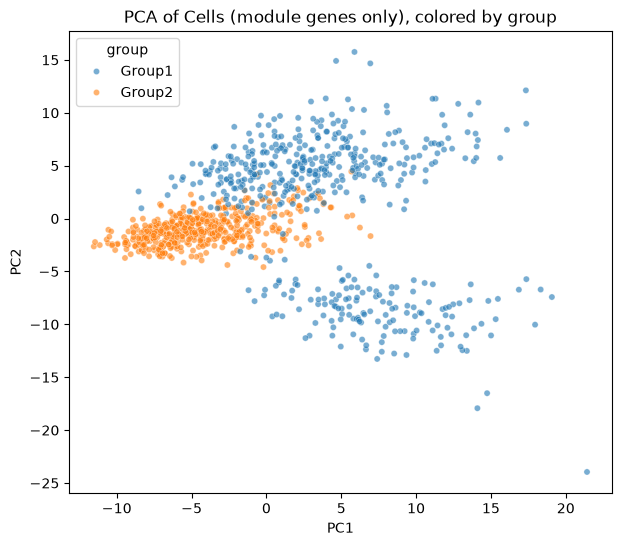

In [32]:
%run correlated_with_subtypes_syntheticdata.ipynb
# %run disease-heterogeneity/correlated_with_subtypes_syntheticdata.ipynb  # COLAB -- uncomment this line, comment out the one above

### Step 12: setup

This is where the model code actually lives now -- the data notebook above only generates `counts_df`/`genes_df`/`patients_df`/`cells_df` via `%run`. Builds the cell x gene feature matrix and the same GroupShuffleSplit-by-patient train/test split used by every method below, so all 10 methods are evaluated on identical data -- a fair, apples-to-apples comparison.

**IMPORTANT (macOS-specific, but harmless everywhere else, including Colab):** importing PyTorch (needed for STG) before XGBoost can segfault the Python process on some machines, because both libraries bundle their own OpenMP runtime and the two can conflict once both actually run in the same process. The setup cell below works around this by importing `xgboost` before `torch` and capping both libraries to 1 thread -- this must run before ANY of torch/xgboost/stg are imported.

In [33]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
os.environ["OMP_NUM_THREADS"] = "1"

import warnings
warnings.filterwarnings("ignore")

import collections
import collections.abc
for _name in ("Iterable", "Mapping", "Sequence", "Set", "MutableMapping",
              "MutableSequence", "MutableSet", "Callable", "Hashable",
              "Sized", "Container"):
    if not hasattr(collections, _name):
        setattr(collections, _name, getattr(collections.abc, _name))

from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.feature_selection import RFE, SelectKBest, mutual_info_classif
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier  # import before torch -- see note above
import torch
torch.set_num_threads(1)
from stg import STG
from group_lasso import LogisticGroupLasso

X_df = counts_df.pivot_table(
    index="cell_id", columns="gene_id", values="expression", aggfunc="sum", fill_value=0
)
cell_labels = cells_df[["cell_id", "group"]].drop_duplicates().set_index("cell_id").loc[X_df.index]
y = (cell_labels["group"] == "Group2").astype(int).values
gene_types = genes_df.set_index("gene_id").loc[X_df.columns, "gene_type"]
groups_arr = cell_labels.index.map(lambda c: c.split("_")[0]).values  # patient_id per cell

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X_df.values, y, groups=groups_arr))
X_train, X_test = X_df.values[train_idx], X_df.values[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

n_signal_total = int((gene_types == "signal").sum())
n_background_total = int((gene_types == "background").sum())
TOP_K = n_signal_total  # shared selection budget for methods with no natural sparsity

baseline_results = []  # one row per method, filled in by record_result() below
module_recovery_results = []  # one row per (method, module), filled in by record_module_recovery()

def record_module_recovery(method, selected_mask):
    for module in module_names:
        module_mask = (genes_df.set_index("gene_id").loc[X_df.columns, "module_id"] == module).values
        n_in_module = int(module_mask.sum())
        n_recovered = int((selected_mask & module_mask).sum())
        module_recovery_results.append({
            "method": method, "module_id": module,
            "kind": "disease" if module in disease_modules else "distractor",
            "genes_in_module": n_in_module, "genes_recovered": n_recovered,
            "recovery_rate": round(n_recovered / n_in_module, 4)
        })

def record_result(method, train_acc, test_acc, selected_mask, extra=None):
    """selected_mask: boolean array aligned with X_df.columns (True = gene kept/selected)."""
    signal_mask = (gene_types.values == "signal")
    background_mask = (gene_types.values == "background")
    row = {
        "method": method,
        "train_acc": round(float(train_acc), 4),
        "test_acc": round(float(test_acc), 4),
        "n_selected": int(selected_mask.sum()),
        "signal_recovery_rate": round((selected_mask & signal_mask).sum() / n_signal_total, 4),
        "background_leak_rate": round((selected_mask & background_mask).sum() / n_background_total, 4),
    }
    if extra:
        row.update(extra)
    baseline_results.append(row)
    record_module_recovery(method, selected_mask)
    return row

print("Baseline setup complete:", X_train_scaled.shape[0], "train cells,", X_test_scaled.shape[0], "test cells,",
      X_train_scaled.shape[1], "genes")

Baseline setup complete: 800 train cells, 200 test cells, 1000 genes


### Method 1: L1-penalized logistic regression (LASSO)

The headline baseline referenced throughout the thesis. `C=0.0068` was tuned so test accuracy lands in a useful, non-trivial difficulty zone (see the data-generation notebook's own parameter-tuning notes) -- retune if that notebook's Step 2 simulation parameters change.

In [34]:
model_l1 = LogisticRegression(penalty="l1", solver="saga", C=0.0068, max_iter=5000, random_state=42)
model_l1.fit(X_train_scaled, y_train)
record_result("L1", model_l1.score(X_train_scaled, y_train), model_l1.score(X_test_scaled, y_test), model_l1.coef_[0] != 0)
print(baseline_results[-1])

{'method': 'L1', 'train_acc': 0.8113, 'test_acc': 0.8, 'n_selected': 17, 'signal_recovery_rate': np.float64(0.17), 'background_leak_rate': np.float64(0.0)}


### Method 2: STG (Stochastic Gates)

Yamada, Lindenbaum, Negahban & Kluger, *"Feature Selection using Stochastic Gates"* (ICML 2020) -- https://github.com/runopti/stg. Each gene gets a learnable stochastic gate trained jointly with an MLP classifier. `lam` (`=0.2`) is STG's sparsity knob; a gate is "open" (selected) if its probability exceeds 0.5. Unlike L1's convex penalty, STG's continuous/soft gating tends to keep accuracy near-ceiling across a wide `lam` range rather than smoothly trading accuracy for sparsity -- `lam` here is chosen for an illustrative gate pattern, not to match L1's accuracy.

`STG`'s `random_state` constructor argument is accepted but never actually used internally (checked the installed package source) -- `torch.manual_seed`/`np.random.seed` are set explicitly right before training instead.

In [35]:
torch.manual_seed(42)
import numpy as np
np.random.seed(42)

stg_model = STG(
    task_type="classification", input_dim=X_train_scaled.shape[1], output_dim=2,
    hidden_dims=[128, 32], activation="tanh", optimizer="Adam", learning_rate=0.01,
    batch_size=X_train_scaled.shape[0], feature_selection=True, sigma=0.5, lam=0.2,
    random_state=42, device="cpu",
)
stg_model.fit(X_train_scaled, y_train.astype(float), nr_epochs=200,
              valid_X=X_test_scaled, valid_y=y_test.astype(float), print_interval=50)

stg_gate_probs = stg_model.get_gates(mode="prob")
stg_train_acc = (stg_model.predict(X_train_scaled) == y_train).mean()
stg_test_acc = (stg_model.predict(X_test_scaled) == y_test).mean()
record_result("STG", stg_train_acc, stg_test_acc, stg_gate_probs > 0.5)
print(baseline_results[-1])

Epoch: 50: loss=0.169183 valid_loss=0.028213


Epoch: 100: loss=0.166165 valid_loss=0.001365
Epoch: 150: loss=0.160002 valid_loss=0.002175


Epoch: 200: loss=0.159725 valid_loss=0.031921
{'method': 'STG', 'train_acc': 1.0, 'test_acc': 0.985, 'n_selected': 113, 'signal_recovery_rate': np.float64(0.7), 'background_leak_rate': np.float64(0.0478)}


### Method 3: ElasticNet

Logistic regression with a 50/50 mix of L1 and L2 penalties (`l1_ratio=0.5`). Expected to be noticeably less sparse than pure L1 -- the L2 component tends to keep correlated/redundant predictors together instead of arbitrarily zeroing most of them out, so a higher recovery rate here than L1's is expected behavior, not a bug.

In [36]:
model_en = LogisticRegression(penalty="elasticnet", solver="saga", l1_ratio=0.5, C=0.0068, max_iter=5000, random_state=42)
model_en.fit(X_train_scaled, y_train)
record_result("ElasticNet", model_en.score(X_train_scaled, y_train), model_en.score(X_test_scaled, y_test), model_en.coef_[0] != 0)
print(baseline_results[-1])

{'method': 'ElasticNet', 'train_acc': 0.915, 'test_acc': 0.94, 'n_selected': 59, 'signal_recovery_rate': np.float64(0.59), 'background_leak_rate': np.float64(0.0)}


### Method 4: Ridge (L2-only)

Pure L2 penalty -- **never produces an exactly-zero coefficient**, so "nonzero count" isn't a meaningful sparsity metric here. Instead, "selected" = the top-`TOP_K` genes by `|coefficient|`, i.e. "if forced to pick only as many genes as are truly relevant, which ones would Ridge's coefficient ranking pick?"

In [37]:
model_ridge = LogisticRegression(penalty="l2", C=1.0, max_iter=5000, random_state=42)
model_ridge.fit(X_train_scaled, y_train)
ridge_selected = np.zeros(X_train_scaled.shape[1], dtype=bool)
ridge_selected[np.argsort(-np.abs(model_ridge.coef_[0]))[:TOP_K]] = True
record_result("Ridge (top-K)", model_ridge.score(X_train_scaled, y_train), model_ridge.score(X_test_scaled, y_test), ridge_selected)
print(baseline_results[-1])

{'method': 'Ridge (top-K)', 'train_acc': 1.0, 'test_acc': 1.0, 'n_selected': 100, 'signal_recovery_rate': np.float64(0.75), 'background_leak_rate': np.float64(0.0278)}


### Method 5: Group Lasso

The most directly relevant baseline for this thesis: Group Lasso (Yuan & Lin 2006) already treats predefined groups of features as a unit, shrinking whole groups toward zero together -- a simple, existing version of "group-aware" sparsity that the eventual group-aware gating framework (methodology step 4) should be compared against. Genes are grouped by their true `module_id` (background genes each get their own singleton "group", since they don't belong to a real module). Uses the `group-lasso` package's `LogisticGroupLasso`.

In [38]:
gl_groups = np.where(
    (genes_df.set_index("gene_id").loc[X_df.columns, "module_id"] == "none").values,
    np.arange(len(X_df.columns)) + 1000,  # background genes: distinct singleton groups
    genes_df.set_index("gene_id").loc[X_df.columns, "module_id"].astype("category").cat.codes.values
)

model_gl = LogisticGroupLasso(groups=gl_groups, group_reg=0.05, l1_reg=0.0, n_iter=100, random_state=42, supress_warning=True)
model_gl.fit(X_train_scaled, y_train)
gl_train_acc = (model_gl.predict(X_train_scaled) == y_train).mean()
gl_test_acc = (model_gl.predict(X_test_scaled) == y_test).mean()
record_result("GroupLasso", gl_train_acc, gl_test_acc, model_gl.sparsity_mask_)
print(baseline_results[-1])

{'method': 'GroupLasso', 'train_acc': 0.9375, 'test_acc': 0.96, 'n_selected': 59, 'signal_recovery_rate': np.float64(0.54), 'background_leak_rate': np.float64(0.0056)}


### Method 6: Random Forest

An embedded-nonlinear baseline: feature importance from Gini impurity decrease. Like Ridge, has no natural zero-coefficient sparsity, so "selected" = top-`TOP_K` genes by `feature_importances_`.

In [39]:
model_rf = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=1)
model_rf.fit(X_train_scaled, y_train)
rf_selected = np.zeros(X_train_scaled.shape[1], dtype=bool)
rf_selected[np.argsort(-model_rf.feature_importances_)[:TOP_K]] = True
record_result("RandomForest (top-K)", model_rf.score(X_train_scaled, y_train), model_rf.score(X_test_scaled, y_test), rf_selected)
print(baseline_results[-1])

{'method': 'RandomForest (top-K)', 'train_acc': 1.0, 'test_acc': 0.985, 'n_selected': 100, 'signal_recovery_rate': np.float64(0.75), 'background_leak_rate': np.float64(0.0278)}


### Method 7: XGBoost

A gradient-boosted-tree baseline, extremely common in genomics feature-selection pipelines. `n_jobs=1` here matches the OpenMP thread-safety note in the setup cell above. Top-`TOP_K` genes by `feature_importances_` (gain-based).

In [40]:
model_xgb = XGBClassifier(n_estimators=300, max_depth=3, random_state=42, eval_metric="logloss", n_jobs=1)
model_xgb.fit(X_train_scaled, y_train)
xgb_selected = np.zeros(X_train_scaled.shape[1], dtype=bool)
xgb_selected[np.argsort(-model_xgb.feature_importances_)[:TOP_K]] = True
xgb_train_acc = (model_xgb.predict(X_train_scaled) == y_train).mean()
xgb_test_acc = (model_xgb.predict(X_test_scaled) == y_test).mean()
record_result("XGBoost (top-K)", xgb_train_acc, xgb_test_acc, xgb_selected)
print(baseline_results[-1])

{'method': 'XGBoost (top-K)', 'train_acc': 1.0, 'test_acc': 0.98, 'n_selected': 100, 'signal_recovery_rate': np.float64(0.37), 'background_leak_rate': np.float64(0.07)}


### Method 8: L1-penalized linear SVM

A margin-based (rather than likelihood-based) embedded-linear baseline -- same sparsity mechanism as L1 logistic regression (exact zeros), different loss function underneath. Reuses L1's tuned `C=0.0068` rather than being independently tuned.

In [41]:
model_svm = LinearSVC(penalty="l1", dual=False, C=0.0068, max_iter=5000, random_state=42)
model_svm.fit(X_train_scaled, y_train)
record_result("LinearSVM-L1", model_svm.score(X_train_scaled, y_train), model_svm.score(X_test_scaled, y_test), model_svm.coef_[0] != 0)
print(baseline_results[-1])

{'method': 'LinearSVM-L1', 'train_acc': 0.9825, 'test_acc': 0.99, 'n_selected': 57, 'signal_recovery_rate': np.float64(0.25), 'background_leak_rate': np.float64(0.0356)}


### Method 9: Recursive Feature Elimination (RFE)

A wrapper method: repeatedly fits a base estimator (logistic regression here), drops the weakest-ranked features, and refits, until `TOP_K` genes remain. `step=50` (drop 50 genes per iteration, not 1) keeps runtime reasonable on 1000 features.

In [42]:
base_estimator = LogisticRegression(max_iter=1000, random_state=42)
model_rfe = RFE(estimator=base_estimator, n_features_to_select=TOP_K, step=50)
model_rfe.fit(X_train_scaled, y_train)
record_result("RFE (top-K)", model_rfe.score(X_train_scaled, y_train), model_rfe.score(X_test_scaled, y_test), model_rfe.support_)
print(baseline_results[-1])

{'method': 'RFE (top-K)', 'train_acc': 1.0, 'test_acc': 0.995, 'n_selected': 100, 'signal_recovery_rate': np.float64(0.56), 'background_leak_rate': np.float64(0.0489)}


### Method 10: Mutual-information filter (SelectKBest)

A filter method: scores every gene independently by mutual information with the group label, no classifier involved in the ranking itself. Top-`TOP_K` genes are then handed to a plain logistic regression just to report an accuracy number -- the selection itself doesn't depend on that classifier.

In [43]:
selector_mi = SelectKBest(mutual_info_classif, k=TOP_K)
selector_mi.fit(X_train_scaled, y_train)
mi_selected = selector_mi.get_support()

model_on_mi = LogisticRegression(max_iter=2000, random_state=42)
model_on_mi.fit(X_train_scaled[:, mi_selected], y_train)
mi_train_acc = model_on_mi.score(X_train_scaled[:, mi_selected], y_train)
mi_test_acc = model_on_mi.score(X_test_scaled[:, mi_selected], y_test)
record_result("SelectKBest-MI (top-K)", mi_train_acc, mi_test_acc, mi_selected)
print(baseline_results[-1])

{'method': 'SelectKBest-MI (top-K)', 'train_acc': 0.9988, 'test_acc': 0.995, 'n_selected': 100, 'signal_recovery_rate': np.float64(0.77), 'background_leak_rate': np.float64(0.0256)}


### Step 23: full comparison across all 10 methods

                method  train_acc  test_acc  n_selected  signal_recovery_rate  background_leak_rate
                    L1     0.8113     0.800          17                  0.17                0.0000
                   STG     1.0000     0.985         113                  0.70                0.0478
            ElasticNet     0.9150     0.940          59                  0.59                0.0000
         Ridge (top-K)     1.0000     1.000         100                  0.75                0.0278
            GroupLasso     0.9375     0.960          59                  0.54                0.0056
  RandomForest (top-K)     1.0000     0.985         100                  0.75                0.0278
       XGBoost (top-K)     1.0000     0.980         100                  0.37                0.0700
          LinearSVM-L1     0.9825     0.990          57                  0.25                0.0356
           RFE (top-K)     1.0000     0.995         100                  0.56                0.0489


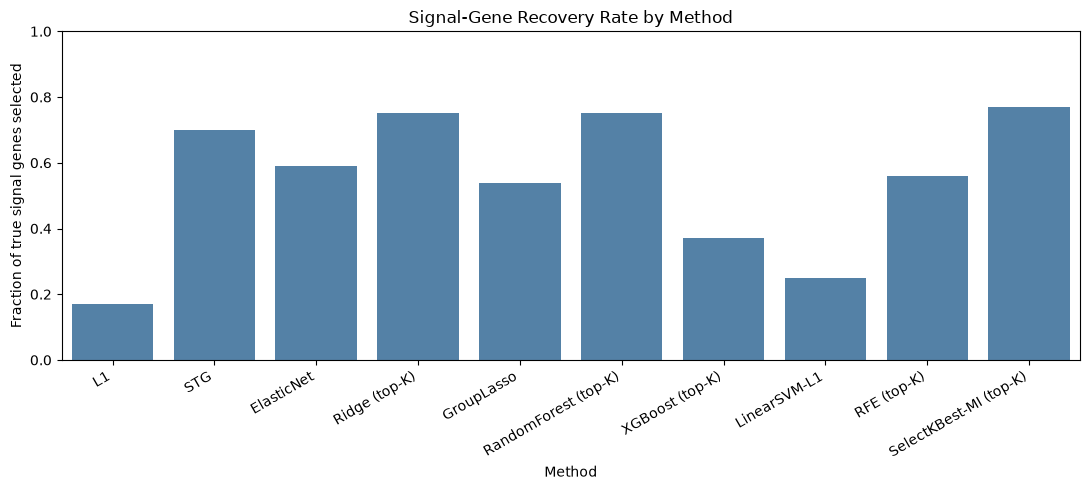

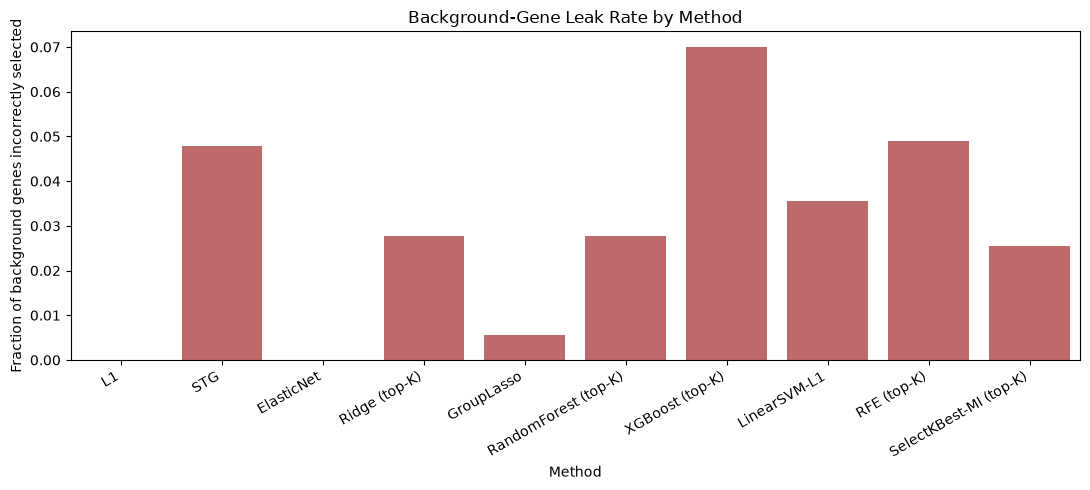


Per-module recovery rate by method:
module_id                 M1    M2    M3    M4
method                                        
ElasticNet              0.96  0.84  0.56  0.00
GroupLasso              0.92  0.64  0.60  0.00
L1                      0.36  0.32  0.00  0.00
LinearSVM-L1            0.44  0.24  0.32  0.00
RFE (top-K)             1.00  0.56  0.68  0.00
RandomForest (top-K)    1.00  1.00  1.00  0.00
Ridge (top-K)           1.00  1.00  1.00  0.00
STG                     1.00  0.88  0.88  0.04
SelectKBest-MI (top-K)  1.00  1.00  1.00  0.08
XGBoost (top-K)         0.60  0.56  0.20  0.12


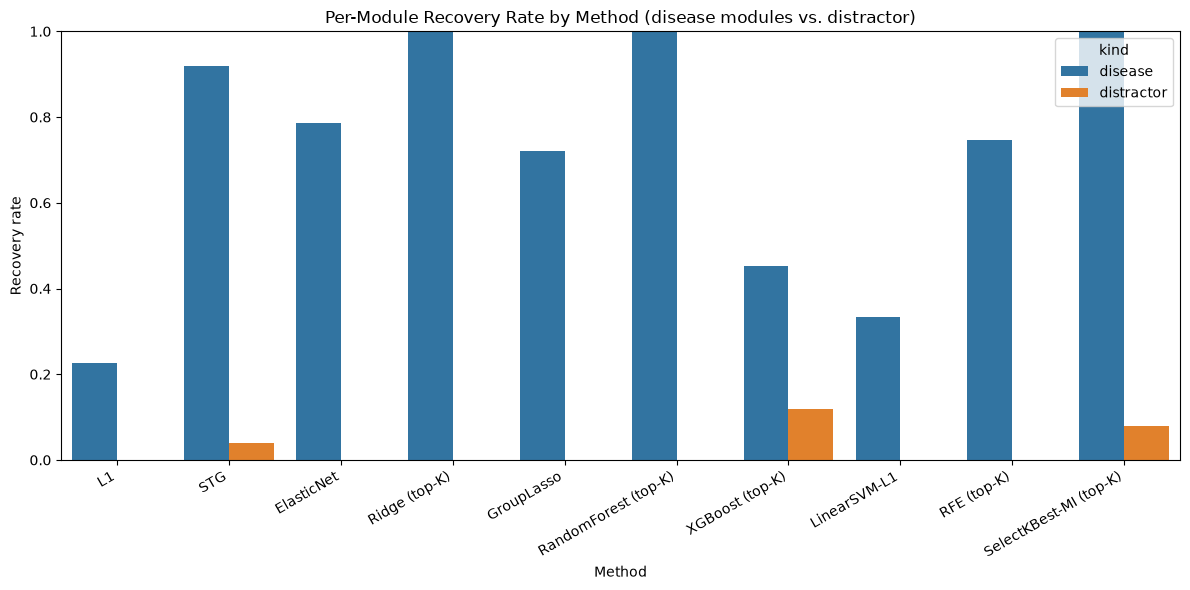

In [44]:
baseline_df = pd.DataFrame(baseline_results)
print(baseline_df.to_string(index=False))

plt.figure(figsize=(11, 5))
sns.barplot(data=baseline_df, x="method", y="signal_recovery_rate", color="steelblue")
plt.title("Signal-Gene Recovery Rate by Method")
plt.xlabel("Method")
plt.ylabel("Fraction of true signal genes selected")
plt.xticks(rotation=30, ha="right")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

plt.figure(figsize=(11, 5))
sns.barplot(data=baseline_df, x="method", y="background_leak_rate", color="indianred")
plt.title("Background-Gene Leak Rate by Method")
plt.xlabel("Method")
plt.ylabel("Fraction of background genes incorrectly selected")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

module_recovery_df = pd.DataFrame(module_recovery_results)
print("\nPer-module recovery rate by method:")
print(module_recovery_df.pivot(index="method", columns="module_id", values="recovery_rate").to_string())

plt.figure(figsize=(12, 6))
sns.barplot(data=module_recovery_df, x="method", y="recovery_rate", hue="kind", errorbar=None)
plt.title("Per-Module Recovery Rate by Method (disease modules vs. distractor)")
plt.xlabel("Method")
plt.ylabel("Recovery rate")
plt.xticks(rotation=30, ha="right")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

In [45]:
subtypes_baseline_results = baseline_df.copy()
subtypes_baseline_results["dataset"] = "subtypes"
subtypes_baseline_results.to_csv("subtypes_baseline_results.csv", index=False)

subtypes_module_recovery = module_recovery_df.copy()
subtypes_module_recovery["dataset"] = "subtypes"
subtypes_module_recovery.to_csv("subtypes_module_recovery.csv", index=False)

print("Saved subtypes_baseline_results.csv:", subtypes_baseline_results.shape)
print("Saved subtypes_module_recovery.csv:", subtypes_module_recovery.shape)

Saved subtypes_baseline_results.csv: (10, 7)
Saved subtypes_module_recovery.csv: (40, 7)


In [46]:
%reset -f

## Combined comparison across all three datasets

Reloads the three checkpointed CSVs (nothing from the individual dataset runs above is still in memory after the last `%reset -f`) and compiles one cross-dataset view: how does each method's behavior change as the data goes from no-modules -> modules -> modules+subtypes?

                method  train_acc  test_acc  n_selected  signal_recovery_rate  background_leak_rate    dataset
                    L1     0.9912     0.975          35                  0.35                0.0000       flat
                   STG     0.9988     1.000          16                  0.16                0.0000       flat
            ElasticNet     0.9975     0.995          83                  0.83                0.0000       flat
         Ridge (top-K)     1.0000     1.000         100                  1.00                0.0000       flat
            GroupLasso     0.9975     0.990          56                  0.56                0.0000       flat
  RandomForest (top-K)     1.0000     1.000         100                  0.99                0.0011       flat
       XGBoost (top-K)     1.0000     0.995         100                  0.38                0.0689       flat
          LinearSVM-L1     0.9975     0.995          44                  0.37                0.0078       flat
 

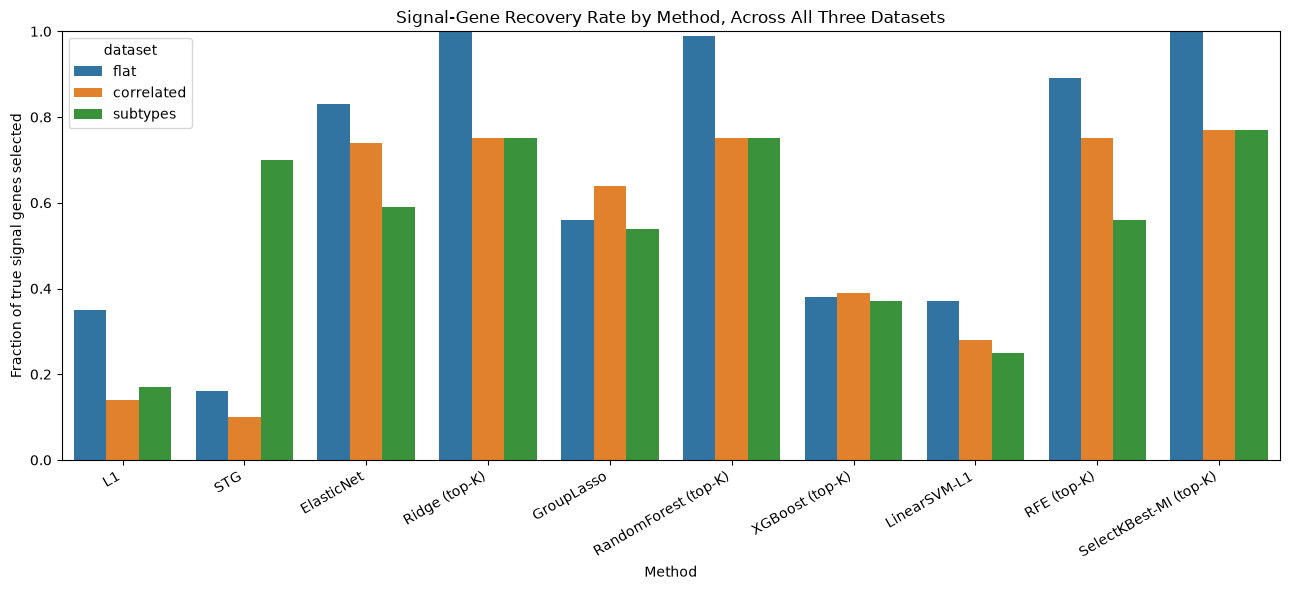

In [47]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

all_baseline_results = pd.concat([
    pd.read_csv("flat_baseline_results.csv"),
    pd.read_csv("correlated_baseline_results.csv"),
    pd.read_csv("subtypes_baseline_results.csv"),
], ignore_index=True)

print(all_baseline_results.to_string(index=False))

plt.figure(figsize=(13, 6))
sns.barplot(data=all_baseline_results, x="method", y="signal_recovery_rate", hue="dataset")
plt.title("Signal-Gene Recovery Rate by Method, Across All Three Datasets")
plt.xlabel("Method")
plt.ylabel("Fraction of true signal genes selected")
plt.xticks(rotation=30, ha="right")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

module_id                            M1    M2    M3    M4
method                 dataset                           
ElasticNet             correlated  0.96  1.00  1.00  0.00
                       subtypes    0.96  0.84  0.56  0.00
GroupLasso             correlated  0.88  0.88  0.80  0.00
                       subtypes    0.92  0.64  0.60  0.00
L1                     correlated  0.24  0.12  0.20  0.00
                       subtypes    0.36  0.32  0.00  0.00
LinearSVM-L1           correlated  0.48  0.36  0.28  0.00
                       subtypes    0.44  0.24  0.32  0.00
RFE (top-K)            correlated  1.00  1.00  1.00  0.00
                       subtypes    1.00  0.56  0.68  0.00
RandomForest (top-K)   correlated  1.00  1.00  1.00  0.00
                       subtypes    1.00  1.00  1.00  0.00
Ridge (top-K)          correlated  1.00  1.00  1.00  0.00
                       subtypes    1.00  1.00  1.00  0.00
STG                    correlated  0.16  0.08  0.16  0.00
              

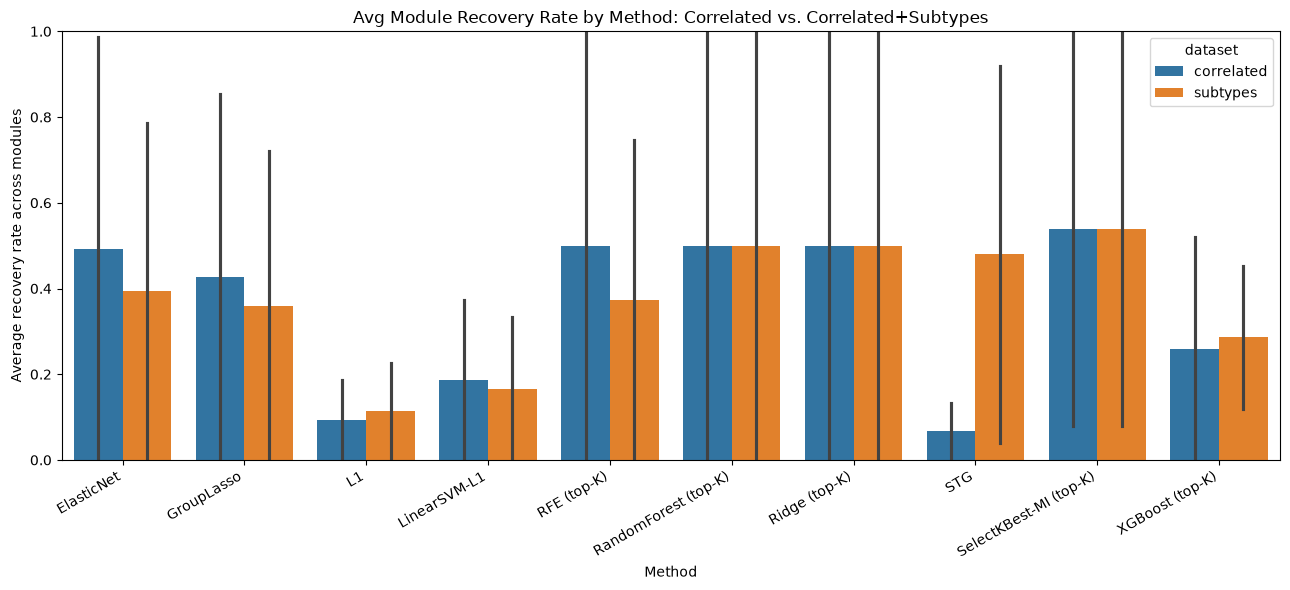

In [48]:
# Module-level comparison: correlated vs. correlated+subtypes only
# (the flat dataset has no module structure, so it has no module_recovery file)

all_module_recovery = pd.concat([
    pd.read_csv("correlated_module_recovery.csv"),
    pd.read_csv("subtypes_module_recovery.csv"),
], ignore_index=True)

print(all_module_recovery.pivot_table(index=["method", "dataset"], columns="module_id", values="recovery_rate").to_string())

plt.figure(figsize=(13, 6))
sns.barplot(
    data=all_module_recovery.groupby(["method", "dataset", "kind"], as_index=False)["recovery_rate"].mean(),
    x="method", y="recovery_rate", hue="dataset"
)
plt.title("Avg Module Recovery Rate by Method: Correlated vs. Correlated+Subtypes")
plt.xlabel("Method")
plt.ylabel("Average recovery rate across modules")
plt.xticks(rotation=30, ha="right")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()